# Organisational Climate Drivers of Employee Turnover

# 1	Business understanding 


ServiceFirst is a national organisation that services large equipment for corporate and private clients in Australia. They are a successful business with 25 years in the industry and their company boasts 250 employees within a multi-layered structure with various departments. This includes remote service staff and office-based support teams spread across regional offices nationwide.

The Executive, People & Culture (P&C), Finance, and IT teams are located at ServiceFirst’s headquarters in Sydney. In addition, there is a customer service and admin team at each regional office led by a regional manager. These managers supervise a team of remote-working service staff within their regions.

Unfortunately, during the pandemic, many employees resigned, which led to high recruitment costs and a loss of experience within the organisation. Therefore, the Executive team engaged the P&C team to better understand the reasons for the resignations. The P&C team initiated a research project to establish current employee satisfaction levels and whether there is a link to resignations. They designed a questionnaire to establish how employees perceive the organisation’s climate.

ServiceFirst aims to reduce recruitment costs and minimise the loss of experienced employees by fostering a more positive organisational climate. Specifically, the goal of the P&C team’s project is to:

1. Identify the dimension(s) of the OCM where employees have scored the lowest, indicating areas of potential dissatisfaction.
2. Analyse the relationship between overall organisational climate (OC) and key factors, including:
   - a. Work location, length of tenure, management responsibilities, intention to quit, and employee sentiment.
   - b. The ten dimensions of OC.
3. Predict which key factors most significantly impact the overall OC, enabling the organisation to target areas for improvement, ultimately supporting increased employee retention.


Please refer to report for further information regarding business understanding.
****

# 2	Data understanding & 3 Data preparation

## 2.1 Import and view the data

The data that was provided is structured and was provided as a comma separated value (csv) file employee_survey.csv.
The follow steps will be undertaken to gain a better understanding of the dataset.
 - Import the Pandas and NumPy libraries. (Numpy is required to perform mathematical functions and statistical analysis. Pandas is able to work with the large structured data tables which are csv files in this case. Pandas is built on top of Numpy so it inherits its performance benefits for numerical operations.)
 - Create a new variable to store the data as a DataFrame.
 - Import the data set 
 - Review the DataFrame 

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Import the data set and call the dataframe 'survey'
survey = pd.read_csv('employee_survey.csv')

# Confirm if imported correctly, by viewing shape, column names and first five rows
print(survey.shape)
print(survey.columns) 
survey.head()

(142, 18)
Index(['id', 'agree', 'workloc', 'workleng', 'manag_resp', 'involved',
       'autonomy', 'direct_manag', 'integrated', 'welfare', 'training',
       'work_press', 'reflexive', 'innovative', 'customers', 'overall_score',
       'intent_quit', 'sentiment'],
      dtype='object')


,id,agree,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment
0,1,Yes,2,3,2,3.195169,3.879956,1.343400,4.920832,2.623486,4.476097,3.903101,2.996662,-2.256064,2.736050,27.82,2,3
1,2,Yes,1,3,2,-1.017589,0.613432,1.053927,-0.147223,1.073410,-1.106388,-0.705966,2.004760,-1.880934,-1.645745,-1.76,2,1
2,8,Yes,1,3,2,1.510066,0.613432,-2.419751,0.486283,0.040025,-0.308890,1.598567,-1.466898,0.744976,2.370901,3.17,2,3
3,15,Yes,1,3,2,1.088790,-0.475410,-1.551332,-0.780730,-1.510051,-1.106388,-0.129833,-1.218922,1.120106,-0.550296,-5.11,2,1
4,20,Yes,2,3,2,-0.596313,-1.564251,-0.393439,-0.147223,0.040025,0.488608,-0.129833,0.268931,0.744976,-1.280595,-2.57,3,3


> The data has been imported correctly. The `survey` dataframe (df) has 18 columns (variables) and 142 rows of data

## 2.2 Describe data

In [2]:
# Review the size and data types of all the columns
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             142 non-null    int64  
 1   agree          142 non-null    object 
 2   workloc        142 non-null    int64  
 3   workleng       142 non-null    int64  
 4   manag_resp     142 non-null    int64  
 5   involved       142 non-null    float64
 6   autonomy       142 non-null    float64
 7   direct_manag   142 non-null    float64
 8   integrated     142 non-null    float64
 9   welfare        142 non-null    float64
 10  training       142 non-null    float64
 11  work_press     142 non-null    float64
 12  reflexive      142 non-null    float64
 13  innovative     142 non-null    float64
 14  customers      142 non-null    float64
 15  overall_score  142 non-null    float64
 16  intent_quit    142 non-null    int64  
 17  sentiment      142 non-null    int64  
dtypes: float64

> The data set consists of three data types (`object` or numbers as either `float64` and `int64`).
> The table below provides further information regarding variables of the 'survey' dataframe.
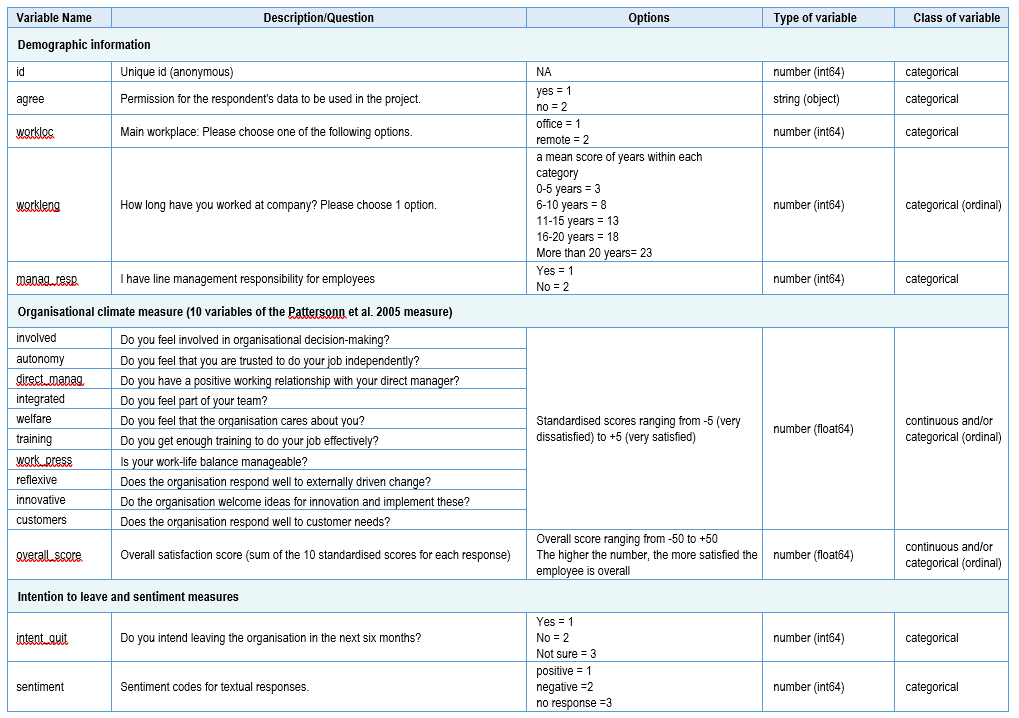
> As shown in the table, the six variables (agree, workloc, workleng, manag_resp, intent_quit, sentiment) are categorical variables and the OCM dimensions including overall score are continuous variables.  All the categorical variables except agree have been provided as numerical data. The agree variable will be checked if all are ‘yes’ and if so will be dropped from the analyses. So it was not necessary to convert this variable to a numerical value.   

## 2.3 Verify data quality and rectify any issues
To assess the quality of the data and rectify issues if required, the following steps were performed:

- Determine if there are any missing data
- Determine if there are any duplicate data
- Identify incorrect values by examining unique values of the categorical data and confirm that `overall_score` equals the sum of the ten OC dimensions
- Determine if there are any outliers
ers.


### Missing data

In [3]:
#check for missing data
survey.isnull().sum()

id               0
agree            0
workloc          0
workleng         0
manag_resp       0
involved         0
autonomy         0
direct_manag     0
integrated       0
welfare          0
training         0
work_press       0
reflexive        0
innovative       0
customers        0
overall_score    0
intent_quit      0
sentiment        0
dtype: int64

### Duplicate data

In [4]:
#check for dublicate rows
survey[survey.duplicated()]

,id,agree,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment


> There are no dublicate rows

### Incorrect values

In [5]:
#check for any anomalies of the categorical values by checking the uniqueness of values
columns = ['id', 'agree', 'workloc', 'workleng', 'manag_resp',
       'intent_quit', 'sentiment']

for column in columns:
    print(f"{column}: {survey[column].nunique()}")

id: 142
agree: 1
workloc: 2
workleng: 5
manag_resp: 2
intent_quit: 3
sentiment: 3


> The number of unique values corresponds with number of values of the categorical variables. So there doesn't seem to be any anomalies at this stage. As expected there is only one unique value for the 'agree' variable as only the data from employees who agreed to provide the data was provided (ie the yes group).

In [6]:
# confirm that overall_score equals the sum of the ten OC dimensions
# List of dimensions to sum
dimensions = ['involved', 'autonomy', 'direct_manag', 'integrated', 
              'welfare', 'training', 'work_press', 'reflexive', 
              'innovative', 'customers']

# Calculate the sum of the specified dimensions for each row
survey['calculated_score'] = survey[dimensions].sum(axis=1).round(2)

# Check if 'overall_score' matches 'calculated_score' for all rows
match = (survey['overall_score'] == survey['calculated_score']).all()

# Display results
print("Do all rows match the overall_score? ", match)


Do all rows match the overall_score?  True


> The overall_score provided matches the calculated score, therefore no corrections required.

Outliers and anomalies in the continuous variables will be checked during data exploration by performing descriptive statistics and examining distributions through visualisations.

## 2.4 Explore data

The data was explored as follows:

- For continuous data variables, check for outliers and if data is normally distributed by:
  - Creating visualisations of the continuous variables via box plots and histograms
  - Calculating the skewness and kurtosis
- Calculate descriptive statistics of continuous and categorical data
- To address business goal 1, review differences of the means of the various OC dimensions and rank from lowest to highest and review mean of the overall OC score and each of the demographic variables
- To address business goal 2 and 3, explore the correlations between the variables

In [7]:
#prior to exploration of data drop variables, id, agree and calculated_score
survey_a = survey.drop(['id','agree','calculated_score'],
                      axis=1)

#view new dataframe
survey_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   workloc        142 non-null    int64  
 1   workleng       142 non-null    int64  
 2   manag_resp     142 non-null    int64  
 3   involved       142 non-null    float64
 4   autonomy       142 non-null    float64
 5   direct_manag   142 non-null    float64
 6   integrated     142 non-null    float64
 7   welfare        142 non-null    float64
 8   training       142 non-null    float64
 9   work_press     142 non-null    float64
 10  reflexive      142 non-null    float64
 11  innovative     142 non-null    float64
 12  customers      142 non-null    float64
 13  overall_score  142 non-null    float64
 14  intent_quit    142 non-null    int64  
 15  sentiment      142 non-null    int64  
dtypes: float64(11), int64(5)
memory usage: 17.9 KB


### Continuous variables
Perform wisualisation of the continuous variables to determine whether the data is normally distributed and if there are any outliers

In [8]:
#drop the categorical variables and call new df survey_c
survey_c = survey_a.drop(['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment'],
                    axis=1)

# View new DataFrame.
print(survey_c.info())
survey_c.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   involved       142 non-null    float64
 1   autonomy       142 non-null    float64
 2   direct_manag   142 non-null    float64
 3   integrated     142 non-null    float64
 4   welfare        142 non-null    float64
 5   training       142 non-null    float64
 6   work_press     142 non-null    float64
 7   reflexive      142 non-null    float64
 8   innovative     142 non-null    float64
 9   customers      142 non-null    float64
 10  overall_score  142 non-null    float64
dtypes: float64(11)
memory usage: 12.3 KB
None


,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score
0,3.195169,3.879956,1.343400,4.920832,2.623486,4.476097,3.903101,2.996662,-2.256064,2.736050,27.82
1,-1.017589,0.613432,1.053927,-0.147223,1.073410,-1.106388,-0.705966,2.004760,-1.880934,-1.645745,-1.76
2,1.510066,0.613432,-2.419751,0.486283,0.040025,-0.308890,1.598567,-1.466898,0.744976,2.370901,3.17
3,1.088790,-0.475410,-1.551332,-0.780730,-1.510051,-1.106388,-0.129833,-1.218922,1.120106,-0.550296,-5.11
4,-0.596313,-1.564251,-0.393439,-0.147223,0.040025,0.488608,-0.129833,0.268931,0.744976,-1.280595,-2.57


#### Boxplots

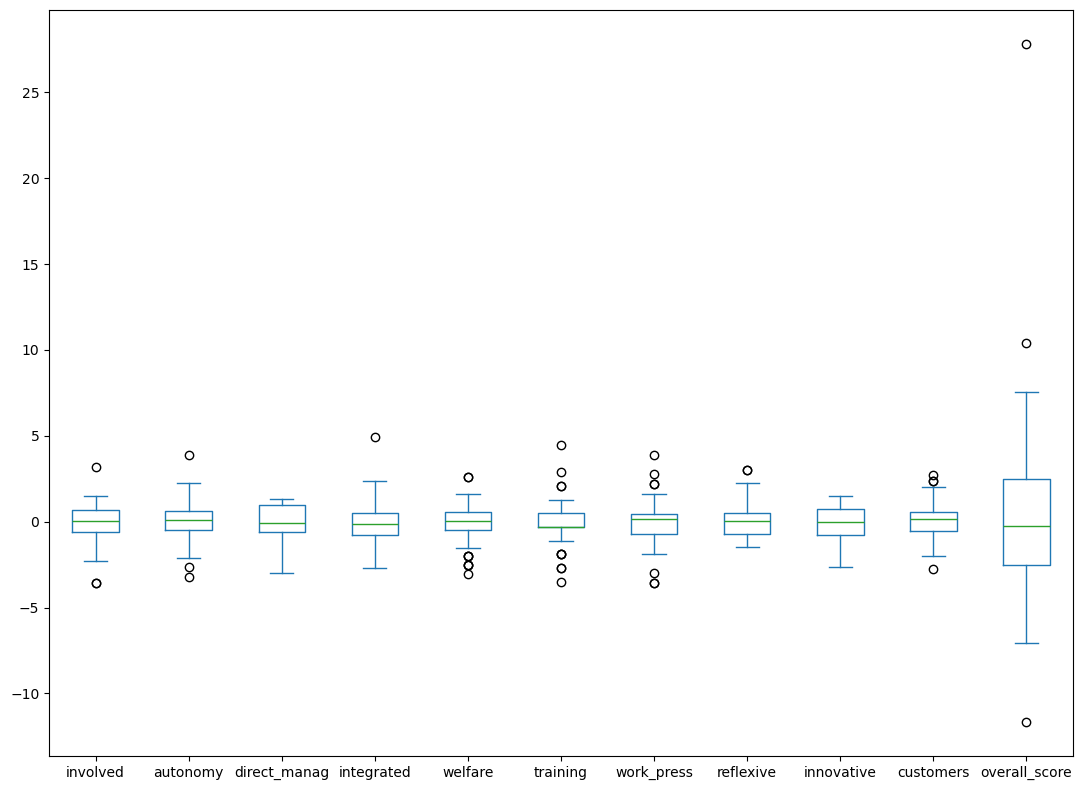

In [9]:
# Import necessary libraries to create boxplots and histograms
import matplotlib.pyplot as plt
import seaborn as sns

# Create the boxplot for each column in the DataFrame
survey_c.plot(kind='box', figsize=(11, 8))

# Show the plot
plt.tight_layout()
plt.show()


> The box plot of the overall_score indicates an outlier that may effect the overall analysis. This outlier will be removed from the analysis.


#### Delete outlier and confirm removal

Index(['involved', 'autonomy', 'direct_manag', 'integrated', 'welfare',
       'training', 'work_press', 'reflexive', 'innovative', 'customers',
       'overall_score'],
      dtype='object')


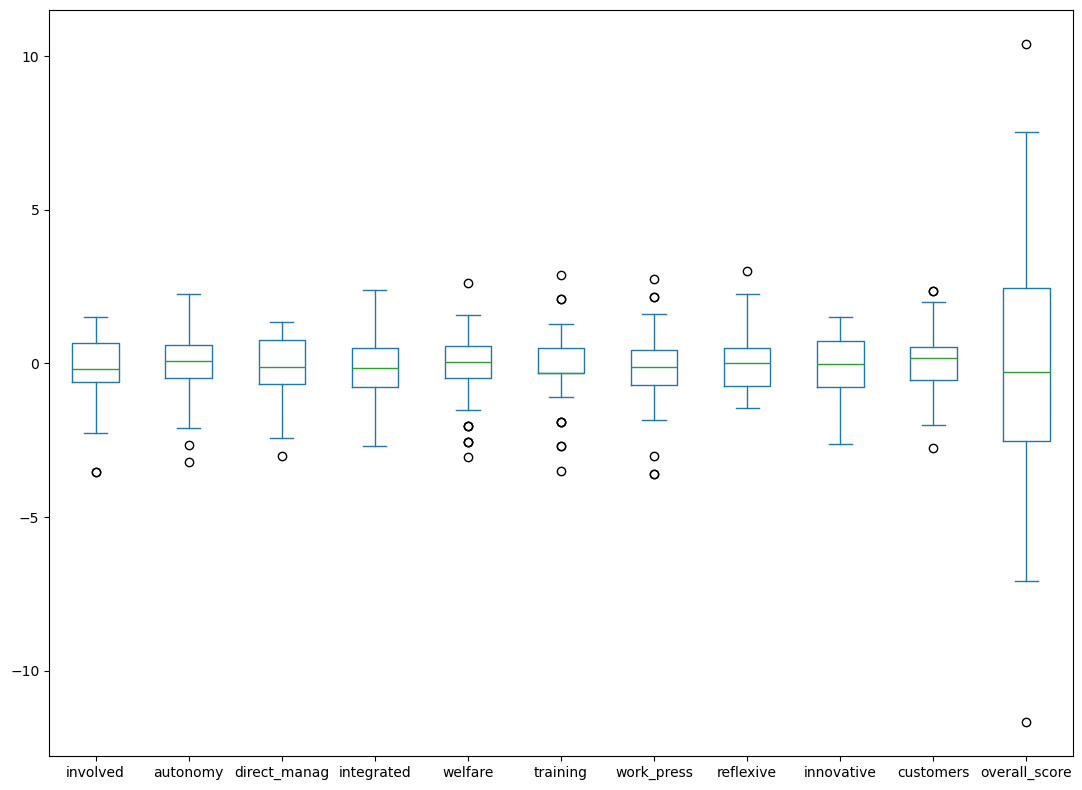

In [10]:
#Delete outlier from survey_a df
#only include rows where 'overall_score' < 25
survey_a = survey_a[survey_a['overall_score'] < 25]

#check with boxplots
survey_c = survey_a.drop(['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment'],
                    axis=1)

survey_c.plot(kind='box', figsize=(11, 8))

# Show the plot
print(survey_c.columns)
plt.tight_layout()
plt.show()


> The output confirms that the outlier has been removed. The boxplot for the OC dimensions indicates normal distribution of the variables. This will be confirmed with the histogram visualisations and calculations of skewness and kurtosis.

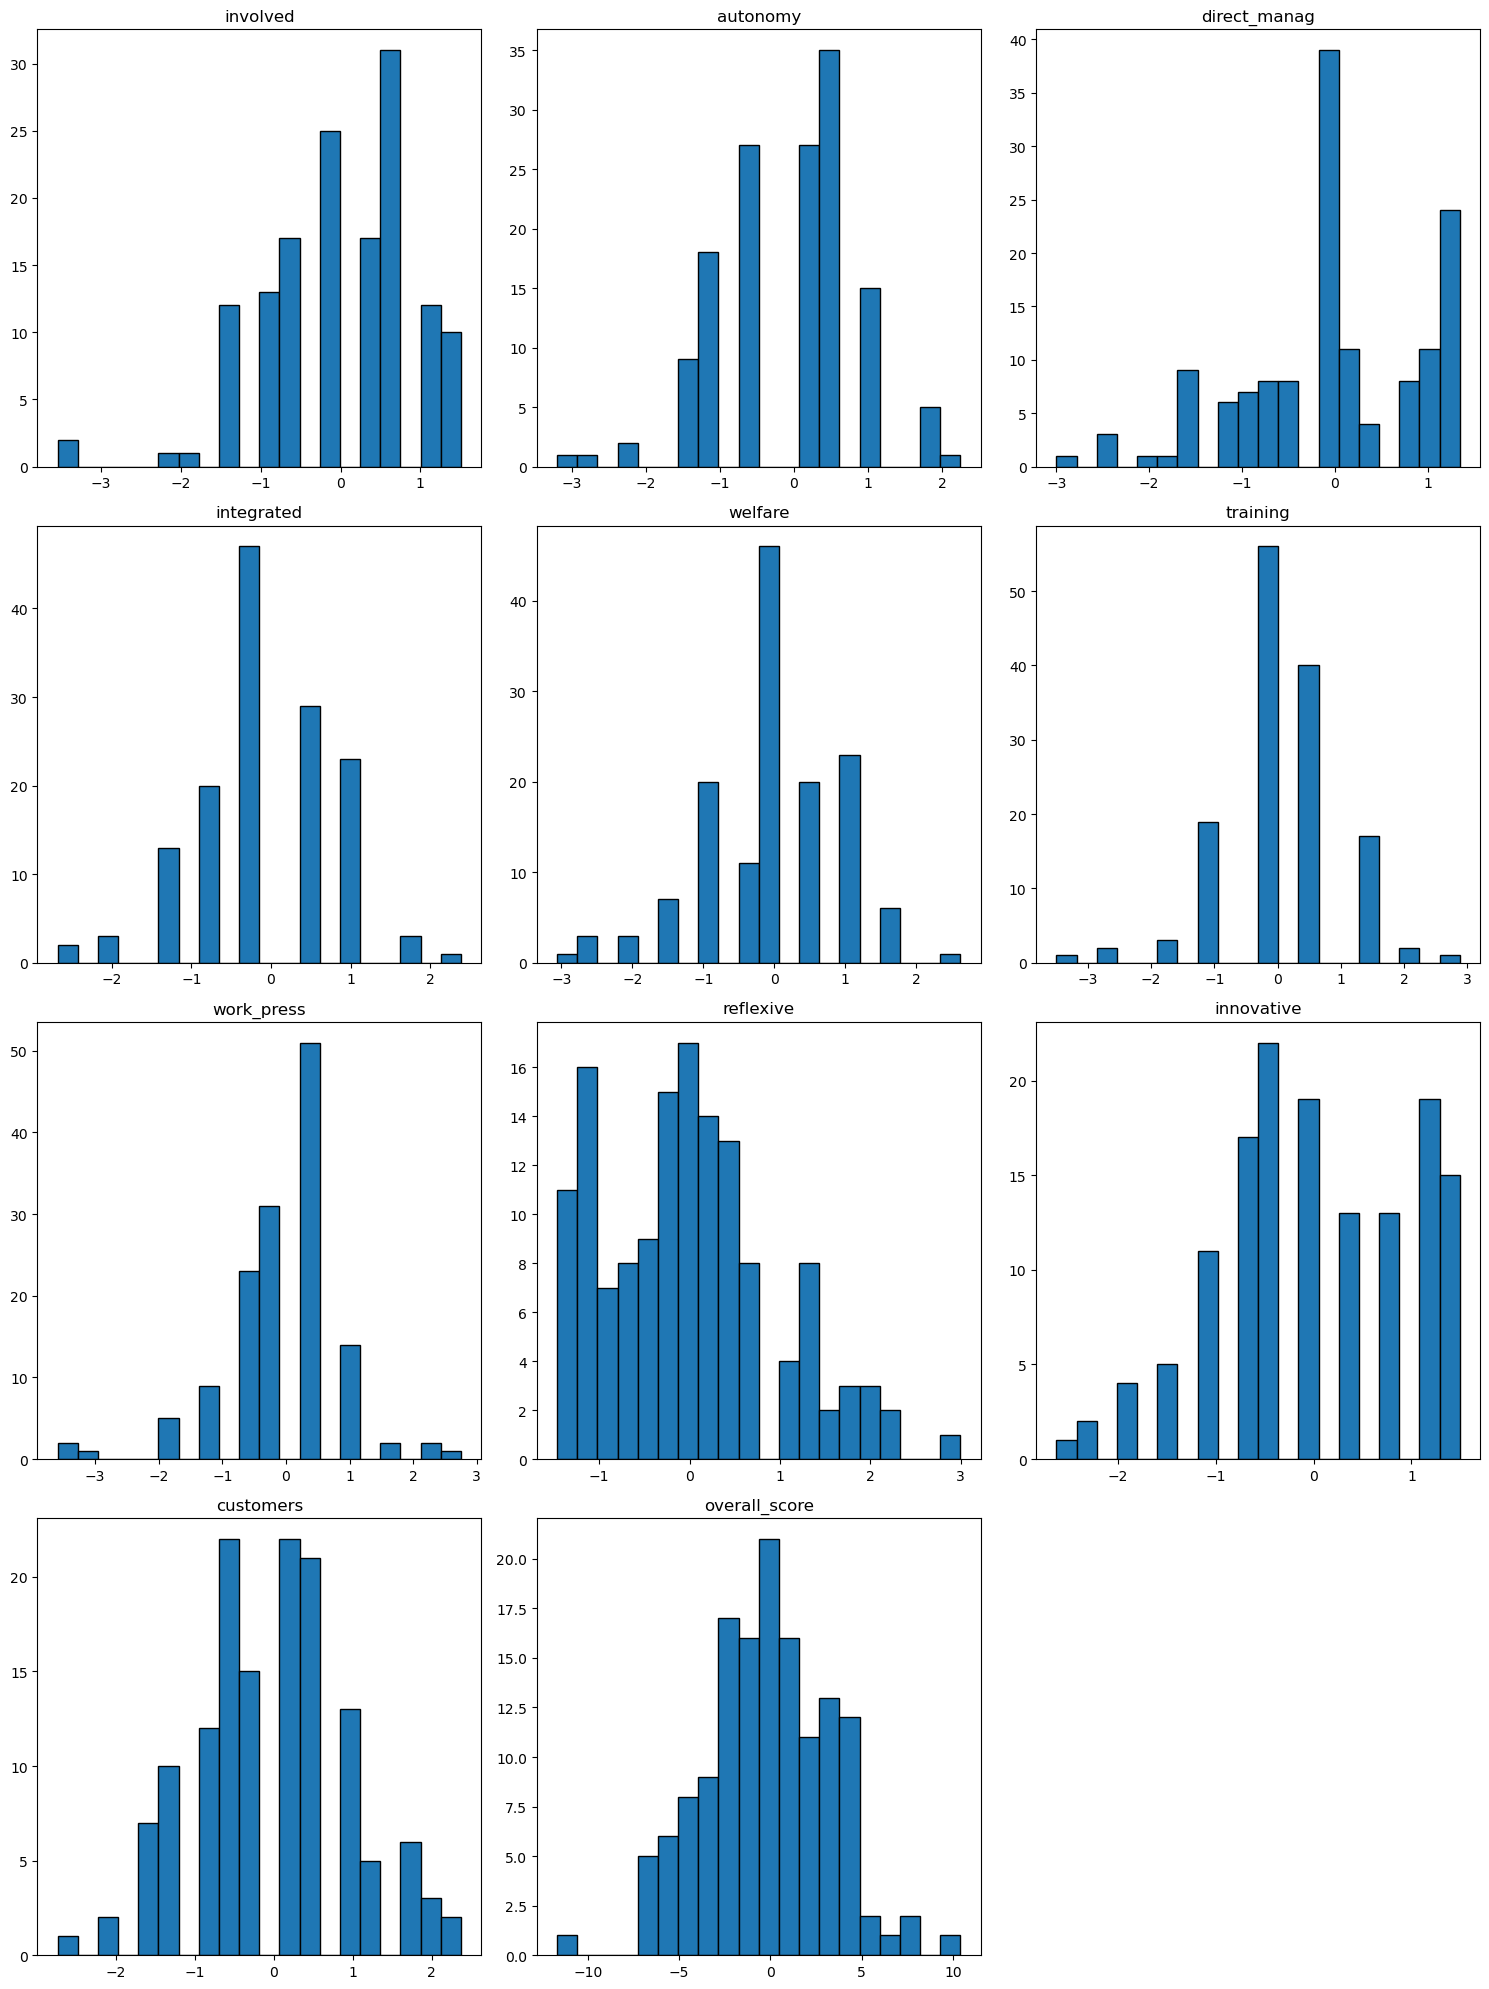

In [11]:
# Create the histograms for each column in the DataFrame
ax = survey_c.hist(figsize=(15, 20), bins=20, layout=(4, 3), edgecolor='black')

# Loop through each subplot to remove grid lines 
for subplot in ax.flatten(): 
    subplot.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

#### Compute Skewness and Kurtosis

In [12]:
# Calculate skewness
print("Skewness of columns:\n", survey_c.skew().round(2))

Skewness of columns:
 involved        -0.74
autonomy        -0.41
direct_manag    -0.45
integrated      -0.32
welfare         -0.51
training        -0.33
work_press      -0.85
reflexive        0.45
innovative      -0.25
customers        0.05
overall_score   -0.03
dtype: float64


In [13]:
# Calculate Kurtosis
print("\nKurtosis of columns:\n", survey_c.kurtosis().round(2))


Kurtosis of columns:
 involved         1.12
autonomy         0.27
direct_manag    -0.17
integrated       0.25
welfare          0.46
training         1.69
work_press       2.71
reflexive       -0.15
innovative      -0.61
customers       -0.13
overall_score    0.41
dtype: float64


> The histogram, skewness, and kurtosis analyses indicate that the variables overall_score and each of the OC dimensions are approximately normally distributed. Skewness values fall between -1 and +1, suggesting low skewness overall. The variables involved, autonomy, direct_manag, integrated, welfare, training, work_press, and innovative have skewness values between -1 and 0, indicating slight left skewness. The variable reflexive shows slight right skewness, while customers and overall_score exhibit virtually no skewness. Kurtosis values are also low and close to 0 for most variables, except for training and work_press, which have kurtosis values of 1.69 and 2.71, respectively, indicating a slightly more peaked distribution.

### Descriptive statistics
#### Continuous variables

In [14]:
#import the library to calculate statistical parameters including standard error of the mean (SEM), 
#and upper and lower confidence intervals
import scipy.stats as stats


# Initialise a dictionary to store the results
results = {}


# List the columns
columns = ['involved', 'autonomy', 'direct_manag', 'integrated', 'welfare', 'training',
           'work_press', 'reflexive', 'innovative', 'customers', 'overall_score']

# Create a loop to means, SEM, upper and lower confidence intervals, an Interquartile range
for column in columns:
    # Calculate the mean and standard error of the mean (SEM)
    mean_val = survey_a[column].mean()
    std_dev = survey_a[column].std() #standard deviation
    sem_val = stats.sem(survey_a[column], nan_policy='omit')  # standard error of the mean
    
    # Calculate the 95% confidence interval
    ci_lower, ci_upper = stats.t.interval(0.95, len(survey_a[column])-1, loc=mean_val, scale=sem_val)
   
    # Calculate Q1, Q3, and IQR
    Q1 = survey_a[column].quantile(0.25)
    Q3 = survey_a[column].quantile(0.75)
    IQR = Q3 - Q1

    # Store the results in a dictionary
    results[column] = {
        'mean': mean_val,
        'Standard deviation': std_dev,
        'Standard error of mean': sem_val,
        'Lower CI': ci_lower,
        'Upper CI': ci_upper,
        'Quartile 1 (Q1)': Q1,
        'Quartile 2 (Q2)': Q3,
        'IQR': IQR
    }

# Convert the results dictionary to a DataFrame for better visualization
results_df = pd.DataFrame(results).T

# Sort the DataFrame by mean in ascending order
results_df = results_df.sort_values(by='mean')

# Display the results
results_df.round(3)


,mean,Standard deviation,Standard error of mean,Lower CI,Upper CI,Quartile 1 (Q1),Quartile 2 (Q2),IQR
overall_score,-0.198,3.443,0.290,-0.771,0.375,-2.520,2.440,4.960
integrated,-0.035,0.913,0.077,-0.187,0.117,-0.781,0.486,1.267
training,-0.032,0.929,0.078,-0.186,0.123,-0.309,0.489,0.797
work_press,-0.028,0.947,0.080,-0.185,0.130,-0.706,0.446,1.152
autonomy,-0.028,0.948,0.080,-0.185,0.130,-0.475,0.613,1.089
involved,-0.023,0.966,0.081,-0.184,0.138,-0.596,0.668,1.264
reflexive,-0.021,0.971,0.082,-0.183,0.140,-0.723,0.517,1.240
customers,-0.019,0.976,0.082,-0.182,0.143,-0.550,0.545,1.095
welfare,-0.019,0.979,0.082,-0.182,0.144,-0.477,0.557,1.033
direct_manag,-0.010,0.997,0.084,-0.176,0.156,-0.683,0.764,1.447


>The results indicate that the overall OC score is slightly negative, with a 95% CI ranging from -0.771 and 0.375 and an IQR of 4.960, suggesting a substantial variation of the climate score. Most OC dimensions have means scores near zero, ranging from -0.035 (integrated) to 0.016 (innovative). The 95% CIs cross zero, suggesting that true mean scores may be slightly negative or positive. 

### Categorical variables

In [15]:
#Obtain percentages for each of the values of the categorical values
# List of categorical columns
columns = ['workloc', 'workleng', 'manag_resp',
       'intent_quit', 'sentiment']

# Calculate percentages for categorical columns
def calculate_percentages(survey_a, columns):
    percentages_dict = {}
    for column in columns:
        counts = survey_a[column].value_counts()
        percentages = (counts / counts.sum()) * 100 #ca
        percentages = percentages.round(2)
        percentages_dict[column] = percentages
    return percentages_dict

# Calculate percentages for each categorical column
percentages_dict = calculate_percentages(survey_a, columns)

# Print the percentages
for column, percentages in percentages_dict.items():
    print(f"Percentages for {column}:\n{percentages}\n")

Percentages for workloc:
workloc
2    66.67
1    33.33
Name: count, dtype: float64

Percentages for workleng:
workleng
13    37.59
8     34.75
3     20.57
18     5.67
23     1.42
Name: count, dtype: float64

Percentages for manag_resp:
manag_resp
2    73.76
1    26.24
Name: count, dtype: float64

Percentages for intent_quit:
intent_quit
2    43.26
1    41.84
3    14.89
Name: count, dtype: float64

Percentages for sentiment:
sentiment
2    51.06
1    26.24
3    22.70
Name: count, dtype: float64



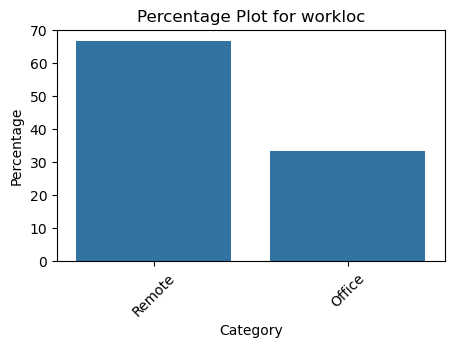

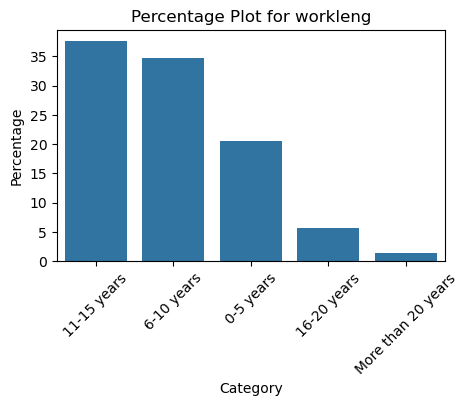

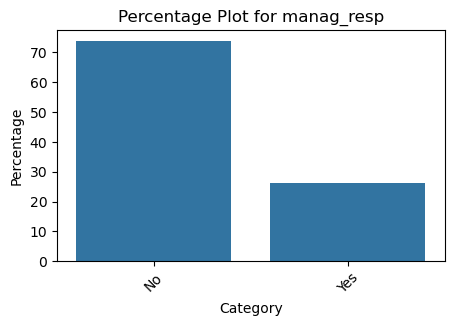

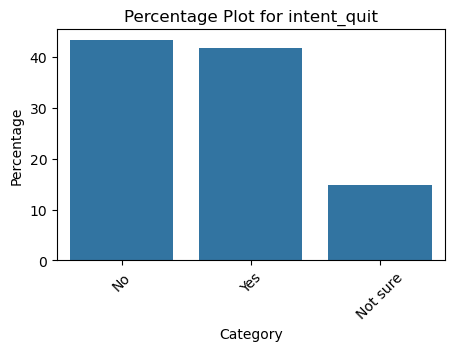

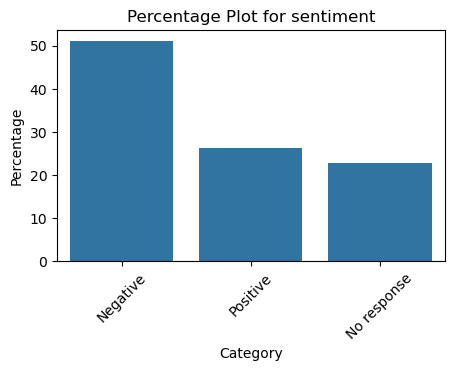

In [16]:
#Plot percentage columns
#libraries to perform visualisations have been already imported

# Define the mappings for each categorical variable
category_mappings = {
    'workloc': {1: 'Office', 2: 'Remote'},
    'workleng': {3: '0-5 years', 8: '6-10 years', 13: '11-15 years', 18: '16-20 years', 23: 'More than 20 years'},
    'manag_resp': {1: 'Yes', 2: 'No'},
    'intent_quit': {1: 'Yes', 2: 'No', 3: 'Not sure'},
    'sentiment': {1: 'Positive', 2: 'Negative', 3: 'No response'}
}

# List of categorical columns
columns = ['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment']

# Function to calculate percentages for categorical columns and plot percentage bar charts
def plot_sns_percentage_with_labels(survey_a, columns, category_mappings):
    for column in columns:
        # Map codes to category names for the current column
        survey_a[column] = survey_a[column].map(category_mappings[column])
        
        # Calculate percentages
        percentages = survey_a[column].value_counts(normalize=True) * 100
        percentages = percentages.reset_index()
        percentages.columns = [column, 'percent']
        
        # Plot
        plt.figure(figsize=(5, 3))
        sns.barplot(data=percentages, x=column, y='percent')
        plt.title(f"Percentage Plot for {column}")
        plt.xlabel('Category')
        plt.ylabel('Percentage')
        plt.xticks(rotation=45)  # Rotate x-axis labels if necessary
        plt.show()

# Plot the percentage bar charts using Seaborn
plot_sns_percentage_with_labels(survey_a, columns, category_mappings)


>The majority of employees that were surveyed were from remote locations (67%) and did not have line management responsibility of employees (74%). Most employees have been with the organisation either 6-10 years (35%) or 11-15 years (38%). The proportion of employees intending to quit in the next 6 months (43%) was very similar to the proportion not intending to quit (42%). In contrast, more employees had negative responses to textual responses (51%) compared to positive (26%) or neutral (26%). 

In [17]:
#The proportions of intent_quit values were calculated for each of the demographic variables (workloc, workleng, manag_resp and sentiment 
# List of columns to create crosstabs with 'intent_quit'
columns = ['workloc', 'workleng', 'manag_resp', 'sentiment']

# Loop through each column and create the crosstab
for column in columns:
    crosstab = (pd.crosstab(survey_a['intent_quit'], survey_a[column], normalize='columns') * 100).round(1)
    print(f"Crosstab between intent to quit and {column}:\n{crosstab}\n")


Crosstab between intent to quit and workloc:
workloc      Office  Remote
intent_quit                
No             40.4    44.7
Not sure       10.6    17.0
Yes            48.9    38.3

Crosstab between intent to quit and workleng:
workleng     0-5 years  11-15 years  16-20 years  6-10 years  \
intent_quit                                                    
No                65.5         34.0         25.0        44.9   
Not sure          17.2         15.1         12.5        14.3   
Yes               17.2         50.9         62.5        40.8   

workleng     More than 20 years  
intent_quit                      
No                          0.0  
Not sure                    0.0  
Yes                       100.0  

Crosstab between intent to quit and manag_resp:
manag_resp     No   Yes
intent_quit            
No           44.2  40.5
Not sure     16.3  10.8
Yes          39.4  48.6

Crosstab between intent to quit and sentiment:
sentiment    Negative  No response  Positive
intent_quit    

>More employees intend to quit in the next six months if they were located in the office, if they worked over 11 years, if they had management responsibility or if they scored negatively in textual responses.  

### Explore differences in overall organisational climate (OC) means for each of the demographic variables
    1. Office vs Remote
    2. Years in company
    3. Management responsibility
    4. Intent to quit
    5. Sentiment

In [18]:

#import scipy.stats to calculate standard error mean (SEM)
from scipy.stats import sem

# List of categorical columns
columns = ['workloc', 'workleng', 'manag_resp', 'intent_quit', 'sentiment']

# Create a dictionary to store the results
OC_avg_dict = {}

# Loop through each column and calculate the mean overall score, standard deviation and standard error mean
for column in columns:
    OC_avg_dict[column] = survey_a.groupby(column)['overall_score'].agg([np.mean, np.std, sem]).reset_index()

# Assign names to the columns within each DataFrame
for column, df in OC_avg_dict.items():
    df.columns = [column, 'mean_overall_score', 'std_deviation', 'std_error']

# View the results for each column
for column, df in OC_avg_dict.items():
    print(f"Average Overall Score for {column}:\n{df}\n")


Average Overall Score for workloc:
  workloc  mean_overall_score  std_deviation  std_error
0  Office           -0.413404       3.425337   0.499637
1  Remote           -0.090000       3.464423   0.357328

Average Overall Score for workleng:
             workleng  mean_overall_score  std_deviation  std_error
0           0-5 years           -0.170690       3.620924   0.672389
1         11-15 years            0.766226       3.557798   0.488701
2         16-20 years           -0.521250       3.672401   1.298390
3          6-10 years           -1.295510       2.947753   0.421108
4  More than 20 years            2.050000       1.767767   1.250000

Average Overall Score for manag_resp:
  manag_resp  mean_overall_score  std_deviation  std_error
0         No           -0.031346       3.472202   0.340477
1        Yes           -0.665676       3.360024   0.552385

Average Overall Score for intent_quit:
  intent_quit  mean_overall_score  std_deviation  std_error
0          No           -0.336721   

>Those working in the office have lower overall OC scores than those working remotely (where less employees intent to quit,). Employees with longer tenure (more than 20 years) have a notably positive mean overall score (M=2.05, SD=1.76), while employees in the 6-10 year range have the most negative score (M=-1.30, SD=2.95). This may suggest that employees newer to the company (0-5 years) and those with the longest tenure tend to view the organisational climate more positively, while mid-tenure employees, especially those with 6-10 years, have more negative perceptions. Employees with management responsibilities have a slightly more negative mean score (M=-0.666, SD=3.36) compared to those without (M=-0.031, SD=3.47). 

Before exploring correlations and hypothesis testing, convert the categorical variables back to numerical values.

In [19]:
# Reverse mappings: Swap keys and values for each category mapping
reverse_category_mappings = {col: {v: k for k, v in mapping.items()} for col, mapping in category_mappings.items()}

# Function to convert categorical values back to numerical values
def convert_to_numerical(survey_a, columns, reverse_mappings):
    for column in columns:
        survey_a[column] = survey_a[column].map(reverse_mappings[column])
    return survey_a

survey_a = convert_to_numerical(survey_a, columns, reverse_category_mappings)


survey_a.head()

,workloc,workleng,manag_resp,involved,autonomy,direct_manag,integrated,welfare,training,work_press,reflexive,innovative,customers,overall_score,intent_quit,sentiment
1,1,3,2,-1.017589,0.613432,1.053927,-0.147223,1.073410,-1.106388,-0.705966,2.004760,-1.880934,-1.645745,-1.76,2,1
2,1,3,2,1.510066,0.613432,-2.419751,0.486283,0.040025,-0.308890,1.598567,-1.466898,0.744976,2.370901,3.17,2,3
3,1,3,2,1.088790,-0.475410,-1.551332,-0.780730,-1.510051,-1.106388,-0.129833,-1.218922,1.120106,-0.550296,-5.11,2,1
4,2,3,2,-0.596313,-1.564251,-0.393439,-0.147223,0.040025,0.488608,-0.129833,0.268931,0.744976,-1.280595,-2.57,3,3
5,2,3,1,0.246239,0.613432,1.053927,0.486283,0.556717,-0.308890,-0.705966,-0.474995,-1.880934,-0.550296,-0.96,3,3


### Explore correlations between variables

<Axes: >

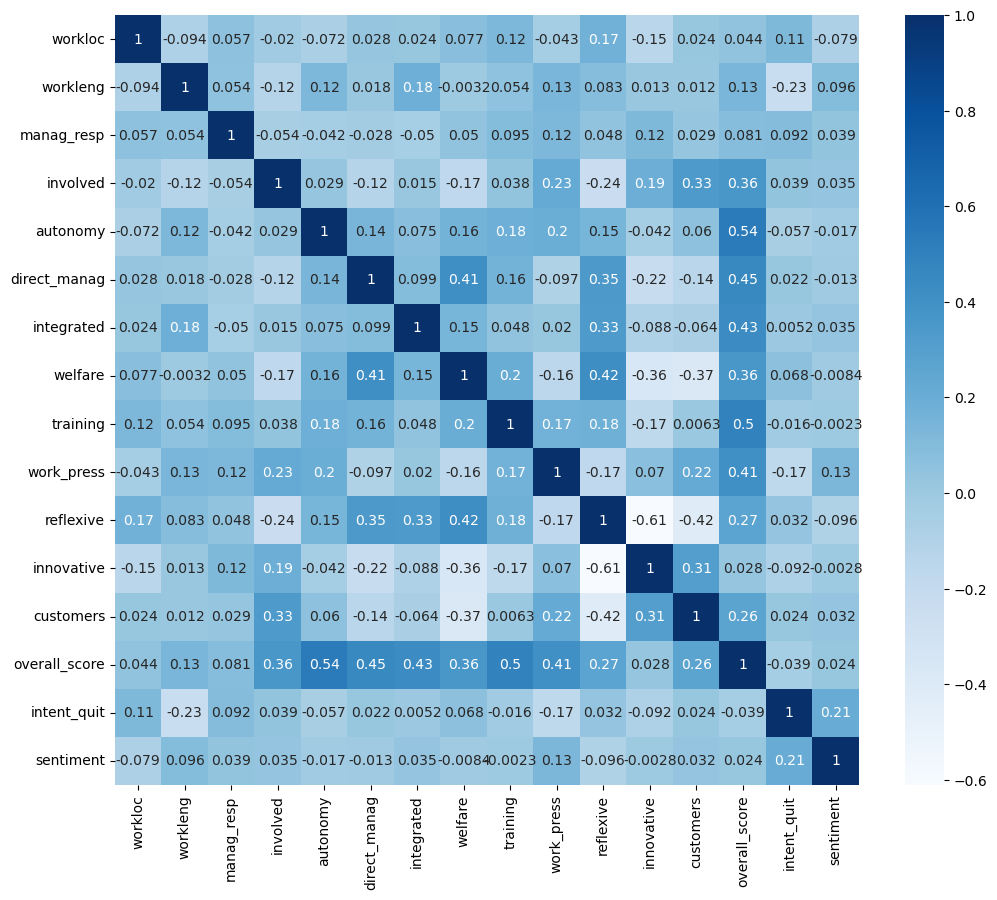

In [20]:
#visualise the correlations between the variables using the heatmap

# Set the size of the figure 
plt.figure(figsize=(12, 10 ))

# Check the correlation with a heatmap
sns.heatmap(survey_a.corr(),
            annot=True,
            cmap='Blues')

> Based on the outputs of the correlation coefficient (Pearson's r), we can conclude the following:
>- 'overall score' of organisational climate measure has a very weak  to almost no correlation ($-0.044\le r\le0.081$) with the  variables 'workloc', 'manag_resp', 'intent_quit', 'sentiment' and one of the organisational climate measure  'innovative'.
>- 'overall score' of organisational climate measure has a very weak  positive correlation ($r = 0.13$) with the variable 'workleng'
>- 'overall score' of organisational climate measure has a weak to moderate positive correlation ($0.26\le r\le0.36$) with the organisational climate measures 'involved', 'welfare', 'reflexive',  , and 'customers'.
>-  'overall score' of organisational climate measure has a substantial to strong positive correlation ($0.41\le r\le0.54$) with the organisational climate measures 'autonomy', 'direct_manag', 'integrated', 'training' and 'work_press'. 

> There are also positive or negative moderate to strong correlations between the independent variables of the organisational climate measure. 
>- For 'reflexive', there is a moderate positive correlation  with 'direct_manag', 'integrated' (r=0.35 and r=0.33 respectively); medium positive correlation with 'welfare' (r=0.42); medium negative correlation with 'customer' (r=-0.42) and strong negative relationship with 'innovative' (r=-0.61)
>- For 'welfare', medium positive correlation with 'direct_manag' (r=0.41)

# 4 Hypothesis testing and modelling

## 4.1 Mean overall OC score and the demographic categorical variables

### Hypothesis
 - **H₀**: There is no difference in the mean overall_score between the categorical values of each demographic variable (i.e., group1 (value= 1) =  group 2 (value= 2)).
 
 - **Hₐ**: There is a significant difference in the mean overall_score between the categorical values of each demographic variable (i.e., group1 (value= 1) ≠  group 2 (value= 2)).


In [21]:

#library for t-test as n>30 however we dont know the population standard deviation
#also can use t-test as 'overall_score' is normally distributed
from scipy.stats import ttest_ind 
from statsmodels.stats.power import TTestIndPower #test the power of the analysis

# Initialise a dictionary to store the results
results = {}

# List of columns to test
columns = ['workloc', 'manag_resp', 'intent_quit', 'sentiment']

# Loop through each column and perform an independent samples t-test
for column in columns:
    # Define the two groups
    group1 = survey_a[survey_a[column] == 1]['overall_score']
    group2 = survey_a[survey_a[column] == 2]['overall_score']
    
    # Perform the t-test with Welch's correction for unequal variances
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit', equal_var=False)  
    
    # Calculate Cohen's d (effect size)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std
    
    # Calculate power of the test
    power_analysis = TTestIndPower()
    power = power_analysis.power(effect_size=cohen_d, nobs1=n1, ratio=n2/n1, alpha=0.05)
    
    # Store the results in the dictionary
    results[column] = {
        'Independent t-test: Statistic': t_stat,
        'p-value': p_value,
        'Cohen\'s d (effect size)': cohen_d,
        'Power of the test': power,
    }

# Convert the results dictionary to a DataFrame for better visualization
results_df = pd.DataFrame(results).T

# Display the results
results_df


,Independent t-test: Statistic,p-value,Cohen's d (effect size),Power of the test
workloc,-0.526491,0.599800,-0.093699,0.081616
manag_resp,-0.977566,0.331899,-0.184211,0.159398
intent_quit,0.518103,0.605359,0.094473,0.080675
sentiment,-0.583247,0.561864,-0.125797,0.094528


>For each of the variables (workloc, manag_resp, intent_quit, and sentiment), the p-values are all greater than 0.05. Therefore, we cannot reject the null hypothesis for all the tests. Therefore, there is no statistically significant difference in the mean overall OC score between the two categorical groups for any of these variables. The effect size (Cohen’s d) for all the variables are close to zero, indicating that means of the two groups differ by less than 0.2 standard deviations, which is a negligible difference. However, the tests have very low power (8% to 16%), indicating a high chance of Type II errors and insufficient sensitivity to detect small effects. Increasing the sample size could improve power, making it easier to detect smaller effects if they exist.

### OC overall score and length of stay
Compare means for length of stay using one-way ANOVA

In [22]:
# Import library to conduct ANOVA (as comparing five groups)
from scipy.stats import f_oneway


# Create the groups to be compared, ie the five unique groups in 'workleng' category
groups = [survey_a[survey_a['workleng'] == group]['overall_score'] for group in survey_a['workleng'].unique()]

#perform the ANOVA
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat}, P-value: {p_val}")



F-statistic: 2.6331706379994206, P-value: 0.036902244791623746


In [23]:
# Import necessary libraries
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower

# Fitting the model
model = ols('overall_score ~ C(workleng)', data=survey_a).fit()
anova_table = anova_lm(model, typ=2)

# Calculate effect size (eta squared and Cohen's f)
eta_squared = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
cohen_f = (eta_squared / (1 - eta_squared)) ** 0.5
print(f"Effect size (Cohen's f): {cohen_f:.3f}")

# Parameters for power calculation
alpha = 0.05
num_groups = len(survey_a['workleng'].unique())
sample_size = len(survey_a['overall_score'])

# Calculate the power of ANOVA
power_analysis = FTestAnovaPower()
power = power_analysis.solve_power(effect_size=cohen_f, nobs=sample_size, alpha=alpha, k_groups=num_groups)
print(f"Power of the test: {power:.3f}")


Effect size (Cohen's f): 0.278
Power of the test: 0.742


> For workleng, there was a significant difference in the mean overall_score between at least two of the categories (F = 2.633, P < 0.05), with a 74% chance of correctly rejecting the null hypothesis. 

In [24]:
#perform Tukey's HSD test to determine which pairing is significant
#import the pairwise_tukeyhsd library
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Flatten the list of groups into a single array and create a corresponding group labels array
data = survey_a['overall_score'].values
groups = survey_a['workleng'].values

# Perform Tukey's HSD test(compares all the possible pairs of group means and indicates which one is significant <0.05)
tukey_result = pairwise_tukeyhsd(data, groups, alpha=0.05)

# Print the results
print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     3      8  -1.1248 0.6116 -3.3045  1.0548  False
     3     13   0.9369 0.7482 -1.2119  3.0858  False
     3     18  -0.3506  0.999 -4.0658  3.3647  False
     3     23   2.2207 0.8954 -4.5807  9.0221  False
     8     13   2.0617 0.0201   0.218  3.9055   True
     8     18   0.7743 0.9743 -2.7733  4.3218  False
     8     23   3.3455 0.6426 -3.3658 10.0568  False
    13     18  -1.2875  0.851 -4.8162  2.2412  False
    13     23   1.2838 0.9842 -5.4176  7.9851  False
    18     23   2.5712 0.8697 -4.7836  9.9261  False
----------------------------------------------------


> In particular, there is a significant difference between those who have stayed for 13 years compared to those who have stayed for 8 years (P < 0.05), with a mean difference of 2.0617 and a confidence interval of [0.218, 3.9055].

## 4.2 Intent_quit proportions and other demographic categorical variables

### Hypothesis
 - **H₀**: There is no difference in the intent_quit proportions between the categorical values of each demographic variable (i.e., group1 (value= 1) =  group 2 (value= 2)).
 
 - **Hₐ**: There is a significant difference in the intent_quit proportions between the categorical values of each demographic variable (i.e., group1 (value= 1) ≠  group 2 (value= 2)).



In [25]:
#import library to perform chi-square test
from scipy.stats import chi2_contingency


# Initialise a dictionary to store the results
results = {}

# List of columns to create crosstabs with 'intent_quit'
columns = ['workloc', 'workleng', 'manag_resp', 'sentiment']

# Loop through each column and create the crosstab
for column in columns:
    # Create the crosstab with raw counts
    crosstab = pd.crosstab(survey_a['intent_quit'], survey_a[column])

    # Perform the chi-square test
    chi2, p_value, dof, ex = chi2_contingency(crosstab)

    
    # Store the results in the dictionary
    results[column] = {
        'Chi-squared': chi2,
        'P-value': p_value,
        'Degrees of Freedom': dof
        }

# Convert the results dictionary to a DataFrame for better visualization
results_df = pd.DataFrame(results).T

# Display the results
results_df.round(3)
    

,Chi-squared,P-value,Degrees of Freedom
workloc,1.836,0.399,2.0
workleng,14.030,0.081,8.0
manag_resp,1.202,0.548,2.0
sentiment,135.756,0.000,4.0


>Only sentiment shows a highly significant difference in the proportions of intent_quit, indicating a strong association between sentiment and intent to quit. 

In [26]:
#calculate effect size and power
#import libraries
from statsmodels.stats.power import GofChisquarePower

# use Cramér's V to calculate the effect size for a chi-square test for intent_quit/sentiment:
# Chi-squared statistic from test
chi2 = 135.76

# Total number of observations
n = survey_a.shape[0]

# Degrees of freedom
df = 4

# Calculate Cramér's V
cramers_v = np.sqrt(chi2 / (n * min(df, n - df)))
print(f"Cramér's V: {cramers_v}")

#calculate the power

# parameters
nobs = survey_a.shape[0] # Total number of observations 
n_bins = 3 # Number of categories in 'intent_quit'


# Calculate the power
power_analysis = GofChisquarePower()
power = power_analysis.solve_power(effect_size=cramers_v, nobs=nobs, alpha=0.05, n_bins=n_bins)
print(f"Power of the test: {power}")

Cramér's V: 0.4906212590768525
Power of the test: 0.9997743342672925


> There is a 99.9% chance of rejecting the null hypothesis

In [27]:
# use Cramér's V to calculate the effect size for a chi-square test for intent_quit/workleng:

# Chi-squared statistic from your test
chi2 = 14.030

# Total number of observations
n = survey_a.shape[0]

# Degrees of freedom
df = 4

# Calculate Cramér's V
cramers_v = np.sqrt(chi2 / (n * min(df, n - df)))
print(f"Cramér's V: {cramers_v}")

#calculate the power

# parameters
nobs = survey_a.shape[0] # Total number of observations 
n_bins = 3 # Number of categories in 'intent_quit'


# Calculate the power
power_analysis = GofChisquarePower()
power = power_analysis.solve_power(effect_size=cramers_v, nobs=nobs, alpha=0.05, n_bins=n_bins)
print(f"Power of the test: {power}")

Cramér's V: 0.15772091340346306
Power of the test: 0.3697001227399601


> 37% chance of rejecting the null hypothesis

In [28]:
# use Cramér's V to calculate the effect size for a chi-square test for intent_quit/workloc:

# Chi-squared statistic from your test
chi2 = 1.836

# Total number of observations
n = survey_a.shape[0]

# Degrees of freedom
df = 4

# Calculate Cramér's V
cramers_v = np.sqrt(chi2 / (n * min(df, n - df)))
print(f"Cramér's V: {cramers_v}")

#calculate the power

# parameters
nobs = survey_a.shape[0] # Total number of observations 
n_bins = 3 # Number of categories in 'intent_quit'


# Calculate the power
power_analysis = GofChisquarePower()
power = power_analysis.solve_power(effect_size=cramers_v, nobs=nobs, alpha=0.05, n_bins=n_bins)
print(f"Power of the test: {power}")

Cramér's V: 0.05705540420447629
Power of the test: 0.08619137431555275


> 8.6% chance of rejecting the null hypothesis

In [29]:
# use Cramér's V to calculate the effect size for a chi-square test for intent_quit/manag_resp:

# Chi-squared statistic from your test
chi2 = 1.202

# Total number of observations
n = survey_a.shape[0]

# Degrees of freedom
df = 4

# Calculate Cramér's V
cramers_v = np.sqrt(chi2 / (n * min(df, n - df)))
print(f"Cramér's V: {cramers_v}")

#calculate the power

# parameters
nobs = survey_a.shape[0] # Total number of observations 
n_bins = 3 # Number of categories in 'intent_quit'


# Calculate the power
power_analysis = GofChisquarePower()
power = power_analysis.solve_power(effect_size=cramers_v, nobs=nobs, alpha=0.05, n_bins=n_bins)
print(f"Power of the test: {power}")

Cramér's V: 0.0461649831989449
Power of the test: 0.07330527181939817


> 7.3% chance of rejecting the null hypothesis

>The results indicate that workloc and manag_resp have p-values greater than 0.05, suggesting no statistically significant difference in the proportions of intent_quit across their categories. However, the power of these tests were very low (<9%), indicating a high likelihood of Type II errors and insufficient sensitivity to detect small effects (i.e., a high probability of not rejecting the null hypothesis even if a true effect exists).
Workleng has a p-value close to 0.05, indicating a borderline association that is not quite significant at the 5% level but may warrant further investigation, especially as the test power is only 37%.
On the other hand, sentiment (Chi-squared = 135.756, p < 0.001, power = 99.9%) shows a highly significant difference in the proportions of intent_quit, indicating a strong association between sentiment and intent to quit. Specifically, those with negative sentiment are more likely to express an intent to quit within the next six months.

## 4.3 Simple linear regression model

In [30]:
#prepare the dataframe and drop unnecessary columns
#as will be testing to hypotheses, will drop all variables except overall_score, welfare and training (see hypothesis 1 & 2)
survey_s = survey_a.drop(['workloc', 'workleng', 'manag_resp', 'involved', 'direct_manag', 'integrated', 
                        'welfare', 'work_press', 'reflexive', 'innovative', 'customers', 'intent_quit', 'sentiment'],
                         axis=1)

#view survey_s
survey_s.head()

,autonomy,training,overall_score
1,0.613432,-1.106388,-1.76
2,0.613432,-0.308890,3.17
3,-0.475410,-1.106388,-5.11
4,-1.564251,0.488608,-2.57
5,0.613432,-0.308890,-0.96


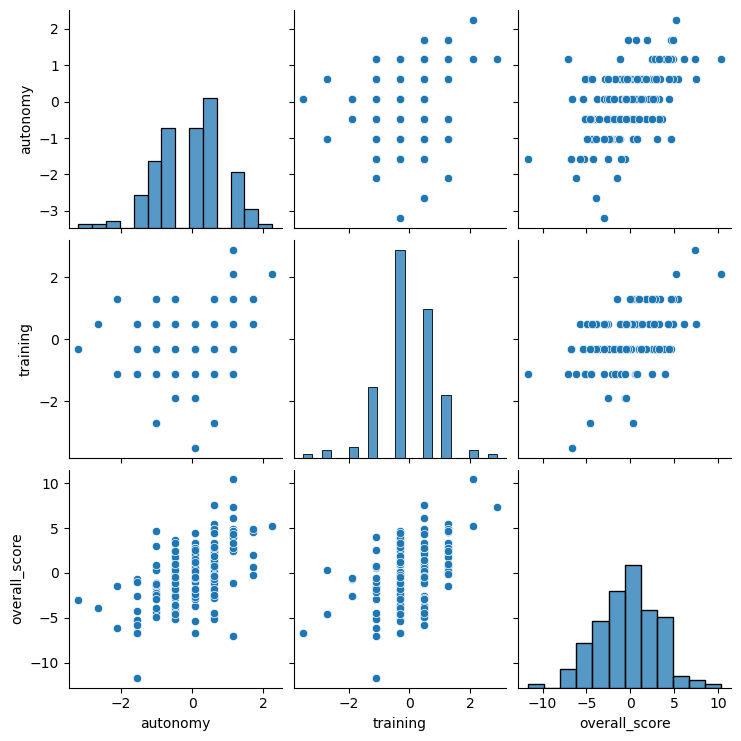

In [31]:
# Create a pairplot to confirm linearity of the variables
sns.pairplot(survey_s)

## Hypothesis 1

- **H₀**: There is no relationship between `overall_score` and `autonomy`.

- **Hₐ**: There is a positive correlation between `overall_score` and `autonomy`, where higher autonomy (feeling trusted to do one's job independently) is associated with a higher overall OCM score. Thus, autonomy can accurately predict `overall_scoe`.
e.


#### specify variables

In [32]:
# Import necessary library.
# Linear regression:
import sklearn
import statsmodels.api as sm 
from sklearn.linear_model import LinearRegression

# Define the dependent variable.
y = survey_s['overall_score'].values.reshape(-1, 1) 

# Define the independent variable.
x = survey_s['autonomy'].values.reshape(-1, 1) 

#### split the data
The data will be split 80:20. This split leaves 80% of the data (around 113 observations) for training and 20% (around 28 observations) for testing. With a small dataset the 80:20 split can help ensure that the model has enough training data to capture patterns.

In [33]:
# Split the data set, and specify the model.
#Data will be split 80:20 

#import module from sklearn to conduct split
from sklearn.model_selection import train_test_split

# Create  the subset for (train:test = 80:20)); 
# Control the shuffling/avoid variation in values between variable.
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size = 0.8,
                                                    random_state = 100)

> There is no output or error message, indicating that Python is happy with the code snippet.

#### fit the model

In [34]:
# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(x_train, y_train) 

LinearRegression()

> The output – `LinearRegression()` – signifies that a linear model has been successfully generated using the values of `x_train` and `y_train`.

In [35]:
# Predict the training set values.
y_pred = lm.predict(x_train) 

# View the output
y_pred

array([[-0.11581097],
       [-0.11581097],
       [-1.20620974],
       [ 2.06498657],
       [-2.2966085 ],
       [-3.38700727],
       [ 0.9745878 ],
       [-1.20620974],
       [-1.20620974],
       [-0.11581097],
       [-1.20620974],
       [ 0.9745878 ],
       [-0.11581097],
       [-0.11581097],
       [-5.56780481],
       [-0.11581097],
       [-1.20620974],
       [-2.2966085 ],
       [ 2.06498657],
       [ 2.06498657],
       [-3.38700727],
       [ 2.06498657],
       [-3.38700727],
       [-3.38700727],
       [-0.11581097],
       [-0.11581097],
       [-0.11581097],
       [-1.20620974],
       [-1.20620974],
       [-2.2966085 ],
       [-0.11581097],
       [ 4.2457841 ],
       [-0.11581097],
       [-0.11581097],
       [ 3.15538534],
       [ 2.06498657],
       [-3.38700727],
       [ 0.9745878 ],
       [ 0.9745878 ],
       [ 0.9745878 ],
       [ 0.9745878 ],
       [-2.2966085 ],
       [ 3.15538534],
       [ 2.06498657],
       [-2.2966085 ],
       [-0

>The output lists all the possible predicted values of the train data set. 

#### create a visualisations


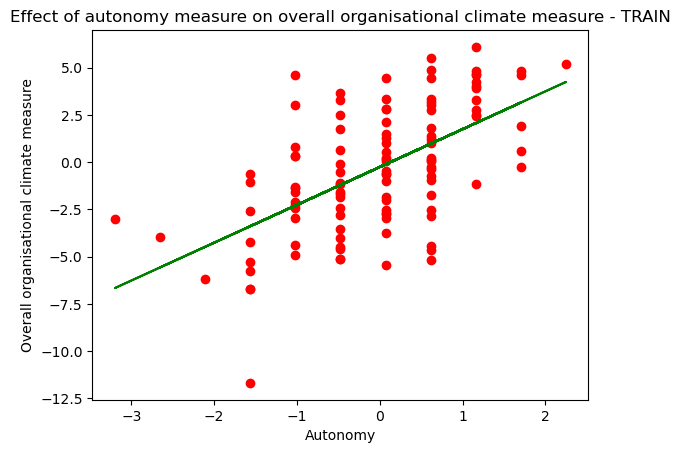

In [36]:
# Create a scatterplot with regression line.
plt.scatter(x_train, y_train, color = 'red')  
plt.plot(x_train, y_pred, color = 'green')

# Set the title and legends for the graph.  
plt.title("Effect of autonomy measure on overall organisational climate measure - TRAIN")
plt.xlabel("Autonomy")
plt.ylabel("Overall organisational climate measure") 

# Print the graph. 
plt.show() 

> The data points are evenly grouped around the best-fit line, indicating homoscedasticity. 

#### determine accuracy of the model

In [37]:
# Accuracy of train data set.
# Import metrics module.
import math
from sklearn import metrics

# Print R-squared value of the test data.
print("R-squared value: ", lm.score(x_train,
                                    y_train)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.  
print('Mean Absolute Error:', metrics.mean_absolute_error(x_train,
                                                          y_pred))  

# Print the MSE. 
print('Mean Square Error:', metrics.mean_squared_error(y_train,
                                                       y_pred,
                                                       squared=False)) 

# Print the RMSE. 
rmse = math.sqrt(metrics.mean_squared_error(x_train,
                                            y_pred))

print('Root Mean Square Error:', rmse)

R-squared value:  0.3426234083370411
Intercept value:  [-0.25403053]
Coefficient value:  [[2.00286063]]
Mean Absolute Error: 0.8115497779589143
Mean Square Error: 2.7164092191628497
Root Mean Square Error: 1.025859478003315


#### > With a data split of 80:20, the following metrics were obtained for autonomy:
> - $R^2=0.343$: The goodness of fit is approximately 34.3%, indicating that only 34% of the variability of 'overall_score' ('Y') is explained by the 'autonomy' measure ('X'). This suggests that the model may not be capturing the data's patterns well, which could mean the relationship between the variables is weak or that other important factors are missing from the model.
> - $\beta_0=-0.254$: The value of 'overall_score' ('Y') when 'autonomy' measure ('X') is equal to zero.
> - $\beta_1=2.00$: The value describes the direction and strength of the relationship between the two variables. Therefore, a positive number indicates that for each 'autonomy' measure ('X') unit, the 'overall_score' ('Y') will increase by 2.00 units.
> - $MAE = 0.81$: MAE indicates the average absolute difference between predicted values and observed values. In this case, on average, predictions are off by about 0.81 units.
> - $MSE = 2.71$: MSE is the average squared difference between the predicted and actual values, suggests the model's predictions are on average 2.71 units squared away from the actual values. 
> - $RMSE = 1.03$: The RMSE is the square root of the MSE, giving an error metric in the same units as the data. The model's predictions deviate from the actual values by about 1.03 units.


Overall, the model explains only a small portion (34.3%) of the variance in the data. The predictions on average deviate from the actual values by approximately 0.81 (MAE) and 1.03 (RMSE). Although MAE and RMSE values are low, these errors are significant when we take into account that the small values for the overall_score (Y). Thus suggesting that the model may not be a good fit. These metrics suggest the model might benefit from more variables for improved accuracy.


#### Evaluate the model

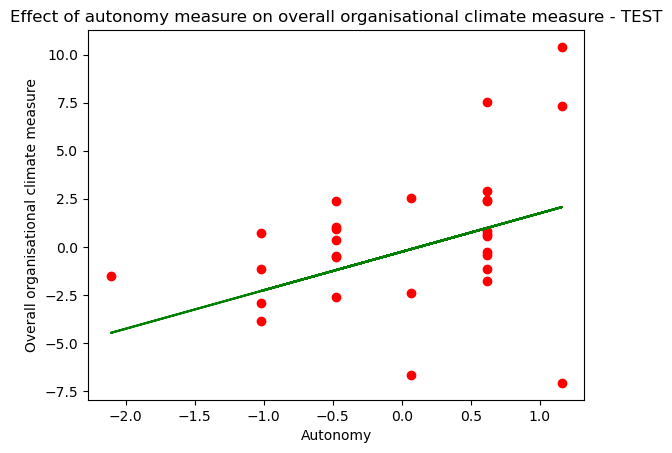

In [38]:
# Predict the test set values. (test = 20% of the data and train was 80% of the data)
y_pred_test = lm.predict(x_test) 

# Create a scatterplot with regression line.
plt.scatter(x_test, y_test, color = 'red') 
plt.plot(x_test, y_pred_test, color = 'green')

# Set the title and legends for the graph.  
plt.title("Effect of autonomy measure on overall organisational climate measure - TEST")
plt.xlabel("Autonomy")
plt.ylabel("Overall organisational climate measure") 

# Print the graph. 
plt.show() 

In [39]:
# Print R-squared value of the test data.
print("R-squared value: ", lm.score(x_test,
                                    y_test)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.   
print('Mean Absolute Error:', metrics.mean_absolute_error(x_test,
                                                          y_pred_test))  

# Print the MSE. 
print('Mean Square Error:', metrics.mean_squared_error(y_test,
                                                       y_pred_test,
                                                       squared=False))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(x_test,
                                              y_pred_test))

print('Root Mean Square Error:', rmse_2)

R-squared value:  0.09723633092337958
Intercept value:  [-0.25403053]
Coefficient value:  [[2.00286063]]
Mean Absolute Error: 0.6841390617486586
Mean Square Error: 3.489068178805746
Root Mean Square Error: 0.8278755375223099


>metrics of train data and test data, dont match so model not accurate

## Hypothesis 2

- **H₀**: There is no relationship between `overall_score` and `training`.

- **Hₐ**: There is a positive correlation between `overall_score` and `training`, where higher training (feeling they receive enough training) is associated with a higher overall OCM score. Thus, training can accurately predict `overall_score`.


#### specify variables

In [40]:
# Define the dependent variable.
y = survey_s['overall_score'].values.reshape(-1, 1) 

# Define the independent variable.
x = survey_s['training'].values.reshape(-1, 1) 

#### split the data

In [41]:
# Split the data set, and specify the model.
#Data will be split 80:20 

# Create  the subset for (train:test = 80:20)); 
# Control the shuffling/avoid variation in values between variable.
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size = 0.8,
                                                    random_state = 100)

#### fit the model

In [42]:
# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(x_train, y_train) 

LinearRegression()

In [43]:
# Predict the training set values.
y_pred = lm.predict(x_train) 

# View the output
y_pred

array([[-3.59386837],
       [ 0.53213077],
       [ 1.90746382],
       [ 1.90746382],
       [ 1.90746382],
       [ 0.53213077],
       [ 0.53213077],
       [ 0.53213077],
       [-0.84320228],
       [ 0.53213077],
       [-0.84320228],
       [ 1.90746382],
       [-0.84320228],
       [-3.59386837],
       [ 0.53213077],
       [-0.84320228],
       [-0.84320228],
       [-0.84320228],
       [ 1.90746382],
       [ 0.53213077],
       [-2.21853532],
       [-0.84320228],
       [-0.84320228],
       [-0.84320228],
       [ 0.53213077],
       [-0.84320228],
       [-2.21853532],
       [ 1.90746382],
       [ 1.90746382],
       [ 0.53213077],
       [ 0.53213077],
       [ 3.28279686],
       [ 0.53213077],
       [ 0.53213077],
       [ 0.53213077],
       [-2.21853532],
       [ 0.53213077],
       [-0.84320228],
       [-0.84320228],
       [-2.21853532],
       [-2.21853532],
       [ 0.53213077],
       [ 1.90746382],
       [ 0.53213077],
       [-0.84320228],
       [-0

#### create a visualisations

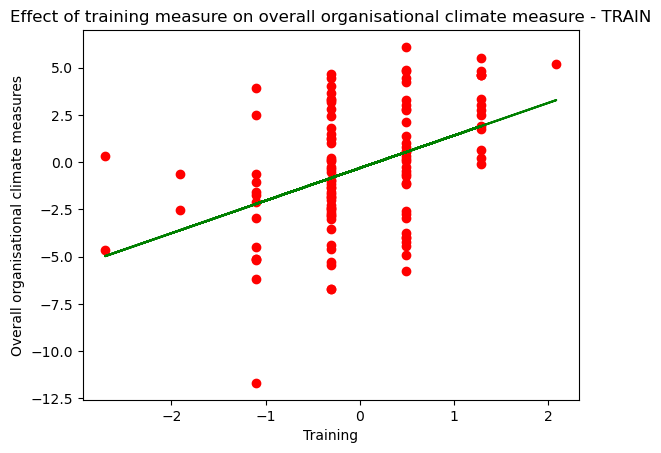

In [44]:
#Visualisation:
import matplotlib.pyplot as plt 

# Create a scatterplot with regression line.
plt.scatter(x_train, y_train, color = 'red')  
plt.plot(x_train, y_pred, color = 'green')

# Set the title and legends for the graph.  
plt.title("Effect of training measure on overall organisational climate measure - TRAIN")
plt.xlabel("Training")
plt.ylabel("Overall organisational climate measures") 

# Print the graph. 
plt.show() 

#### determine accuracy of the model

In [45]:
# Accuracy of train data set.

# Print R-squared value of the test data.
print("R-squared value: ", lm.score(x_train,
                                    y_train)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.  
print('Mean Absolute Error:', metrics.mean_absolute_error(x_train,
                                                          y_pred))  

# Print the MSE. 
print('Mean Square Error:', metrics.mean_squared_error(y_train,
                                                       y_pred,
                                                       squared=False)) 

# Print the RMSE. 
rmse = math.sqrt(metrics.mean_squared_error(x_train,
                                            y_pred))

print('Root Mean Square Error:', rmse)

R-squared value:  0.1865571893200869
Intercept value:  [-0.31050286]
Coefficient value:  [[1.7245604]]
Mean Absolute Error: 0.5259617239680245
Mean Square Error: 3.021701712031409
Root Mean Square Error: 0.6883533885674251


#### > With a data split of 80:20, the following metrics were obtained for training:
> - $R^2=0.187$: indicating that only 18.6% of the variability of 'overall_score' ('Y') is explained by the 'training' measure ('X'). This suggests that the model may not be capturing the data's patterns well, which could mean the relationship between the variables is weak or that other important factors are missing from the model.
> - $\beta_0=-0.312$: The value of 'overall_score' ('Y') when 'training' measure ('X') is equal to zero.
> - $\beta_1=1.72$: The value describes the direction and strength of the relationship between the two variables. Therefore, a positive number indicates that for each 'training' measure ('X') unit, the 'overall_score' ('Y') will increase by 1.72 units.
> - $MAE = 0.53$: MAE indicates the average absolute difference between predicted values and observed values. In this case, on average, predictions are off by about 0.53 units.
> - $MSE = 3.02$: MSE is the average squared difference between the predicted and actual values, suggests the model's predictions are on average 3.02 units squared away from the actual values. 
> - $RMSE = 0.69$: The RMSE is the square root of the MSE, giving an error metric in the same units as the data. The model's predictions deviate from the actual values by about 0.69 units.


#### Evaluate the model and make predictions

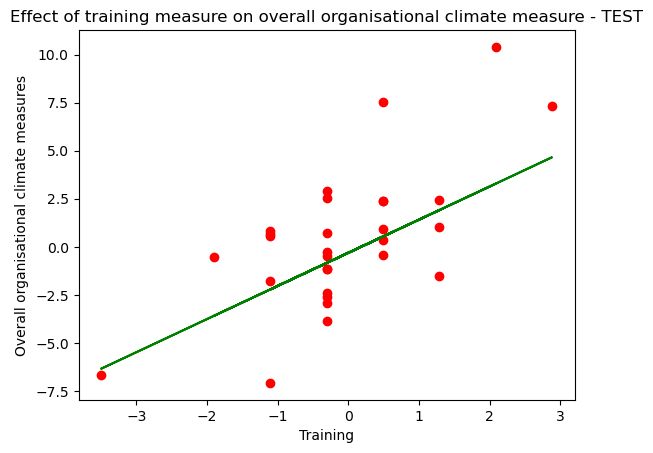

In [46]:
# Predict the test set values. (test = 20% of the data and train was 80% of the data)
y_pred_test = lm.predict(x_test) 

# Create a scatterplot with regression line.
plt.scatter(x_test, y_test, color = 'red') 
plt.plot(x_test, y_pred_test, color = 'green')

# Set the title and legends for the graph.  
plt.title("Effect of training measure on overall organisational climate measure - TEST")
plt.xlabel("Training")
plt.ylabel("Overall organisational climate measures") 

# Print the graph. 
plt.show() 

In [47]:
# Print R-squared value of the test data.
print("R-squared value: ", lm.score(x_test,
                                    y_test)) 

# Print the intercept value.
print("Intercept value: ", lm.intercept_) 

# Print the coefficient value.
print("Coefficient value: ", lm.coef_)

# Print the MAE.   
print('Mean Absolute Error:', metrics.mean_absolute_error(x_test,
                                                          y_pred_test))  

# Print the MSE. 
print('Mean Square Error:', metrics.mean_squared_error(y_test,
                                                       y_pred_test,
                                                       squared=False))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(x_test,
                                              y_pred_test))

print('Root Mean Square Error:', rmse_2)

R-squared value:  0.40279771658090147
Intercept value:  [-0.31050286]
Coefficient value:  [[1.7245604]]
Mean Absolute Error: 0.7267325802173188
Mean Square Error: 2.8378089185837623
Root Mean Square Error: 0.9476659844785157


>metrics of train data and test data, dont match so model not accurate

## 4.4 Multiple linear regression (MLR) model

## The assumptions of MLR are as follows:
1.  Linearity: The relationship between the dependent variable and independent variables should be linear. This means that the change in the dependent variable should be proportional to the change in the independent variables.
2. Independence: The observations should be independent of each other. This means that there should be no correlation or association between the independent variables.
3. No multicollinearity: There should be no multicollinearity between the independent variables. This means that the independent variables should not be too highly correlated with each other.
4. Homoscedasticity: The residuals should have a constant variance across all levels of the independent variables. This means that the spread of the residuals should be the same for all values of the independent variables.
5. Normality: The residuals (the differences between the predicted and actual values of the dependent variable) should be normally distributed.


### Check for linearity and independence

<Axes: >

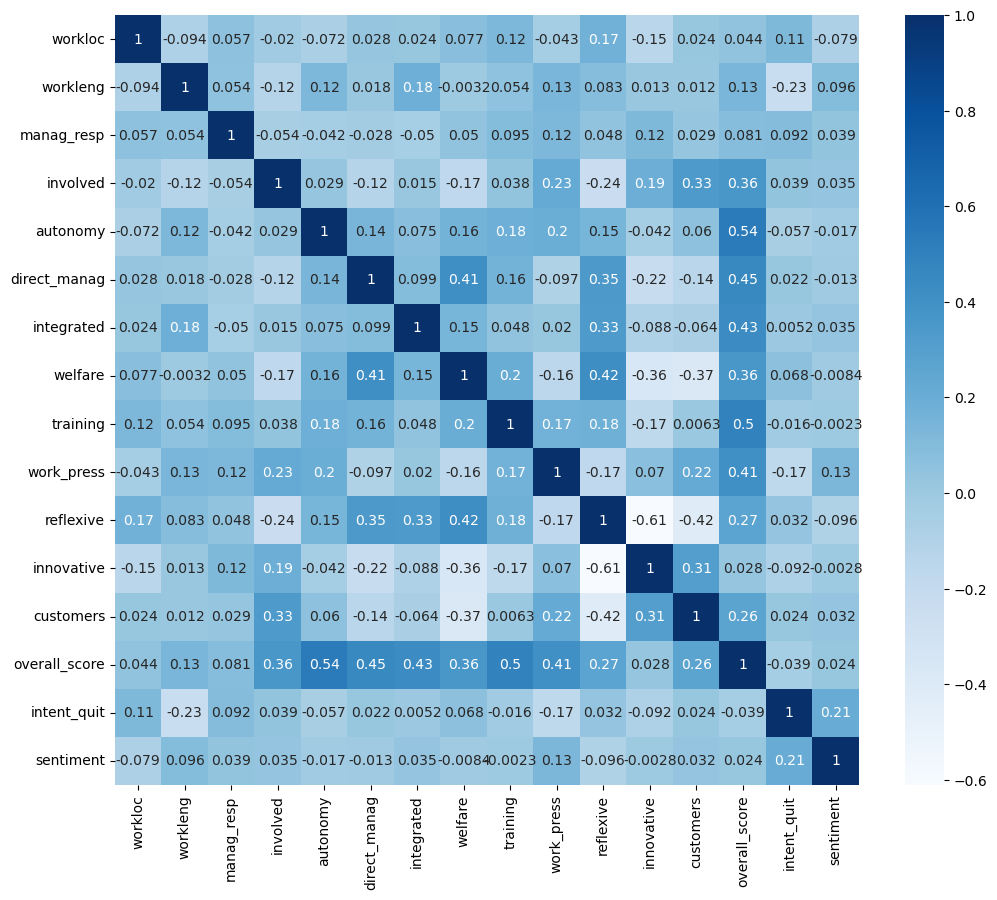

In [48]:
#visualise the correlations between the variables using the heatmap

# Set the size of the figure 
plt.figure(figsize=(12, 10 ))

# Check the correlation with a heatmap
sns.heatmap(survey_a.corr(),
            annot=True,
            cmap='Blues')

As there is virtually a weak to no correlation between overall score and the variables 'workloc', 'manag_resp', 'intent_quit', 'sentiment' and one of the organisational climate measure 'innovative', these will be potentially removed from the MLR. In addition, it was found that intent_quit and sentiment correlate (see previous chi test) which may effect the modelling.

As 'reflexive' is correlating with a number of independent variables this will also potentially removed from the MLR. However these variables will not be dropped until multicollinearity is confirmed with the pairplot and VIF test.

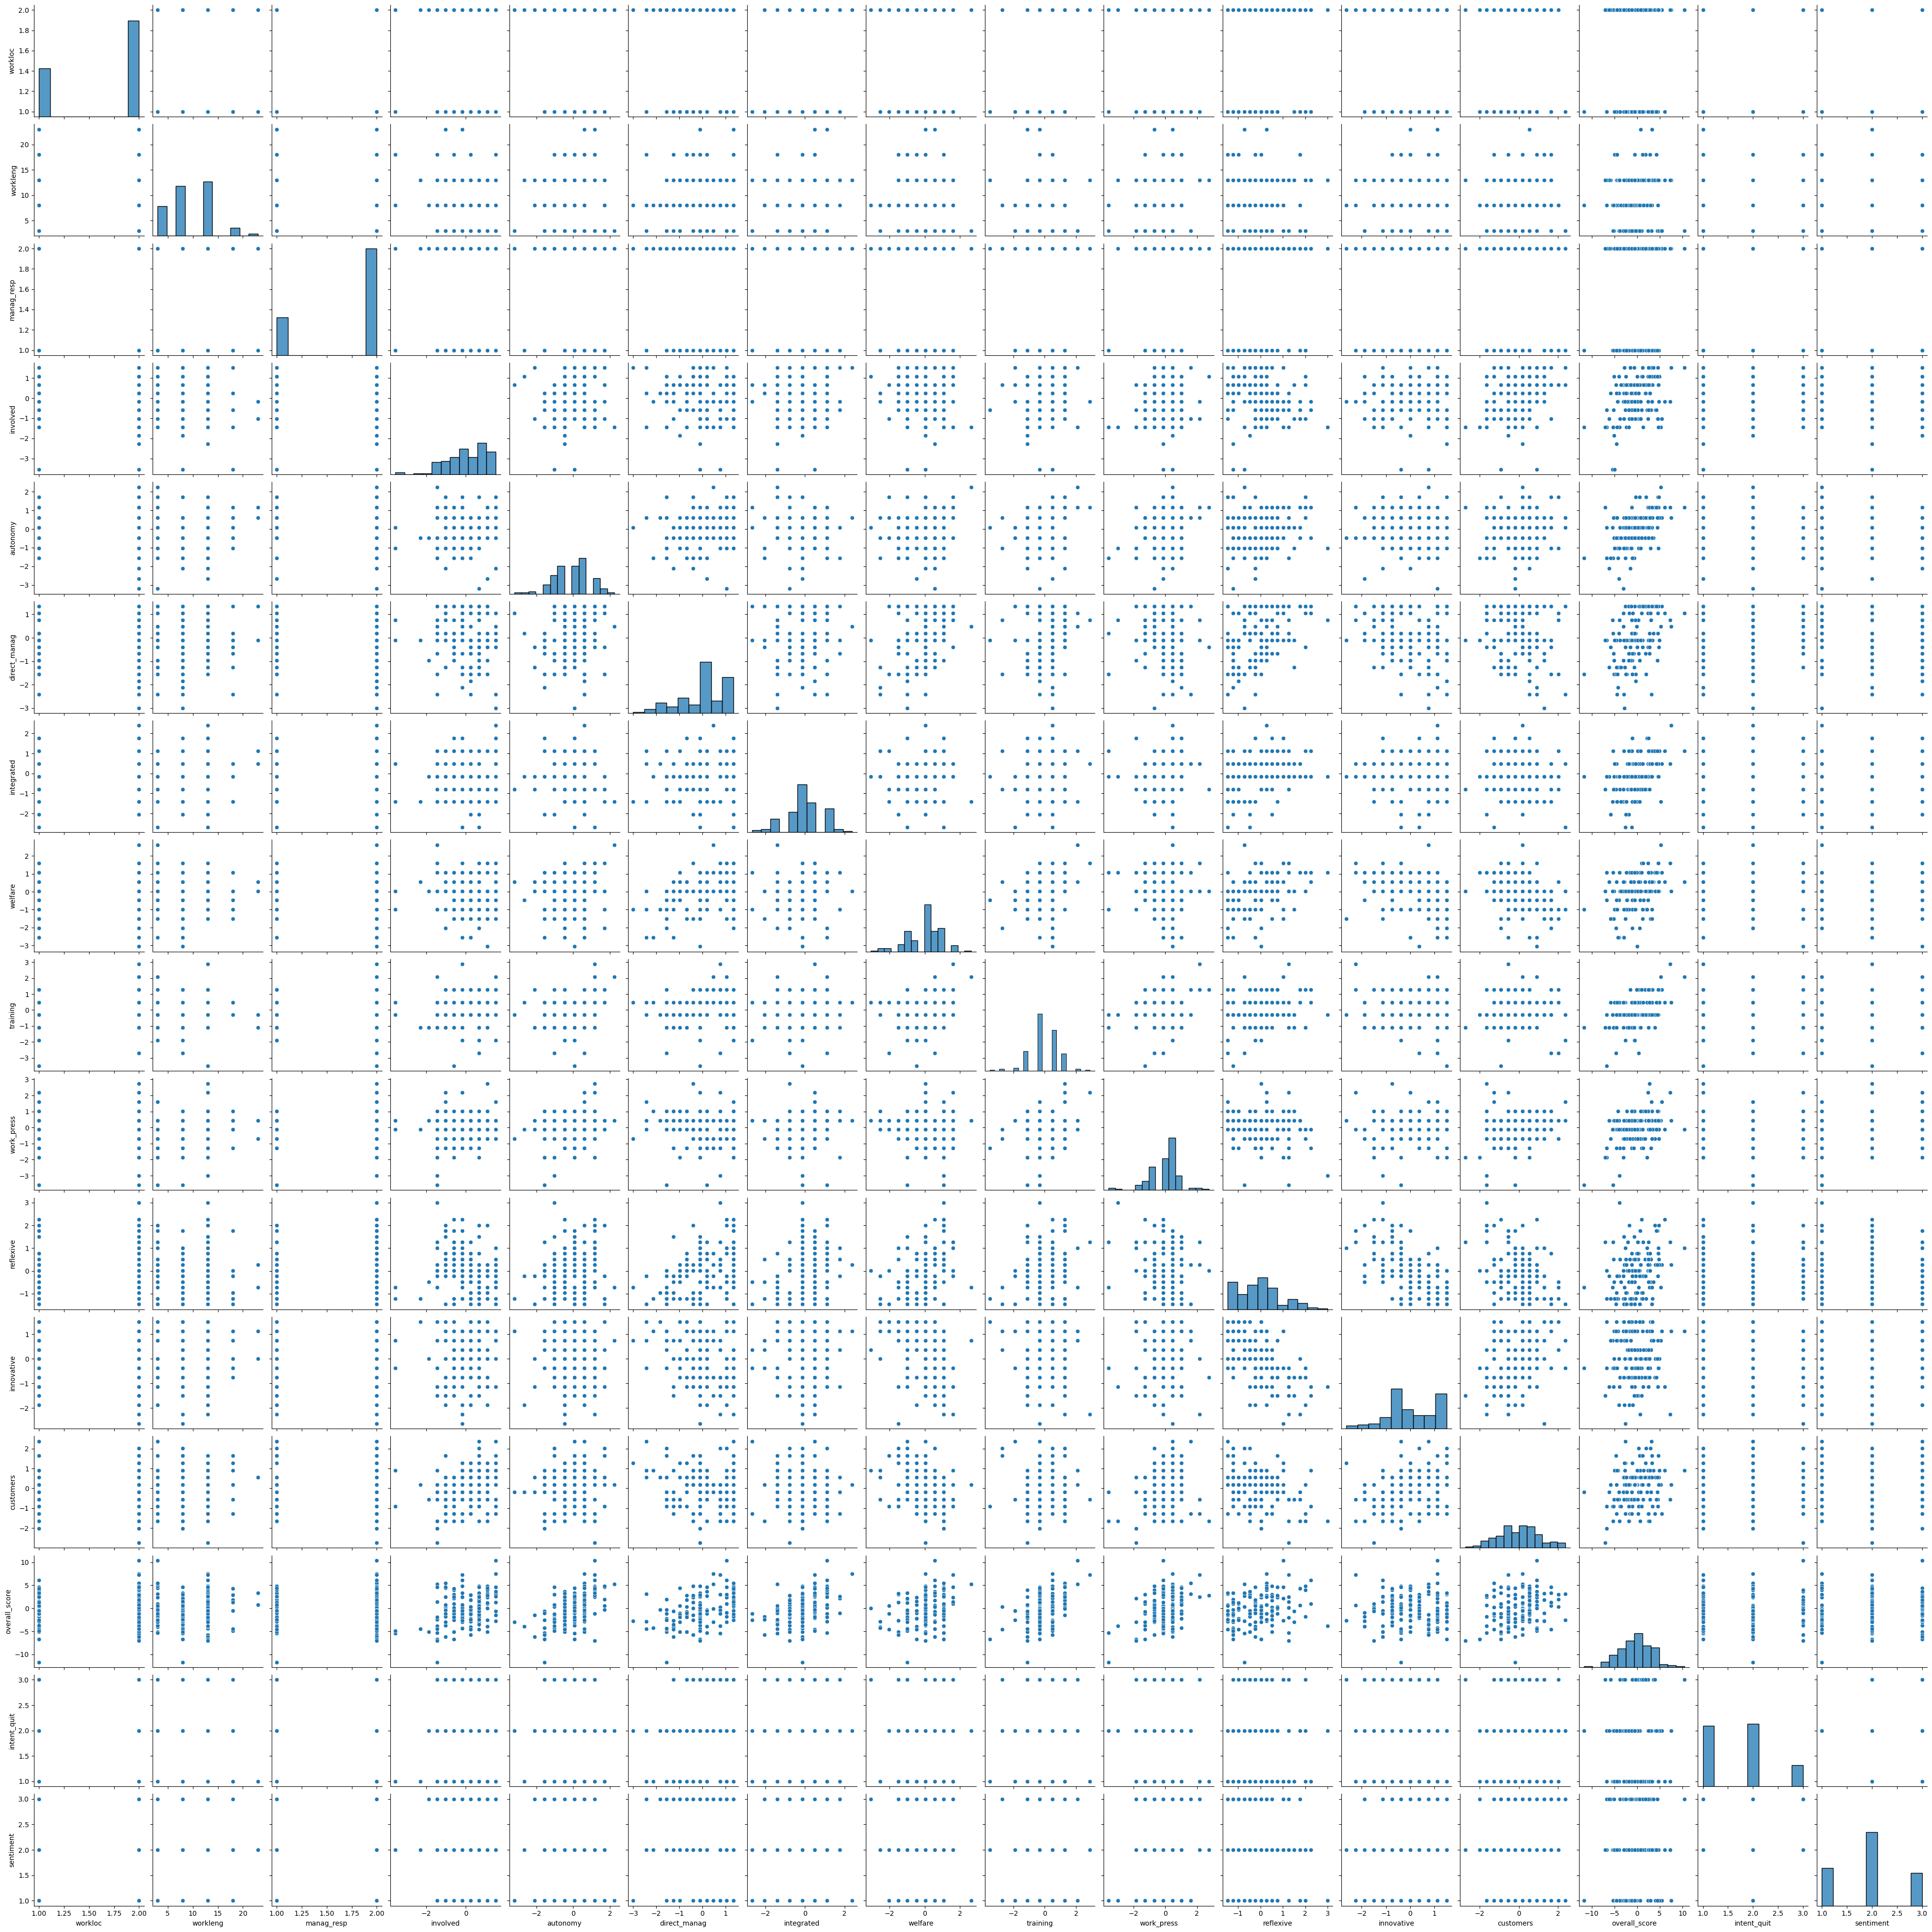

In [49]:
# Create a pairplot.
sns.pairplot(survey_a)

>The output provides subplots consisting of scatterplots and histograms. As was previously found the histograms indicate that 'overall_score' and all sub measures are normally distributed with 'involved' and 'direct_manag' being negatively skewed. there is minimal correlation between overall score and categorical variables.
>
>

### Check for multicollinearity by calculating the VIF

In [50]:
# Independent variables
x = survey_a.drop(columns = 'overall_score')

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)


(141,)
(141, 15)


>Based on the output, y consists of 141 rows and no columns, while x consists of 141 rows and 15 columns. The variables were allocated correctly, and we can proceed with checking for multicollinearity.

In [51]:
# Check multicollinearity.
# Import necessary library.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

         feature        VIF
0        workloc  10.369832
1       workleng   5.571738
2     manag_resp  13.843130
3       involved   1.218104
4       autonomy   1.167159
5   direct_manag   1.289282
6     integrated   1.240506
7        welfare   1.547291
8       training   1.148566
9     work_press   1.299009
10     reflexive   2.419230
11    innovative   1.847663
12     customers   1.454153
13   intent_quit   8.132214
14     sentiment   9.014698


>manag_resp has highest VIF, so will be dropped for next VIF analysis

In [52]:
# Independent variables
x = survey_a.drop(columns = ['overall_score', 'manag_resp'])

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

(141,)
(141, 14)
         feature       VIF
0        workloc  8.323728
1       workleng  5.008108
2       involved  1.215065
3       autonomy  1.161239
4   direct_manag  1.286285
5     integrated  1.208623
6        welfare  1.539569
7       training  1.147531
8     work_press  1.272486
9      reflexive  2.369306
10    innovative  1.731046
11     customers  1.453889
12   intent_quit  7.350472
13     sentiment  8.555854


>sentiment has highest VIF, so will be dropped for next VIF analysis

In [53]:
# Independent variables
x = survey_a.drop(columns = ['overall_score', 'manag_resp', 'sentiment'])

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

(141,)
(141, 13)
         feature       VIF
0        workloc  7.772207
1       workleng  4.227464
2       involved  1.214323
3       autonomy  1.160989
4   direct_manag  1.284499
5     integrated  1.208376
6        welfare  1.539563
7       training  1.145712
8     work_press  1.247154
9      reflexive  2.315425
10    innovative  1.728184
11     customers  1.442456
12   intent_quit  5.758517


>workloc has highest VIF, so will be dropped for next VIF analysis

In [54]:
# Independent variables
x = survey_a.drop(columns = ['overall_score', 'manag_resp', 'sentiment', 'workloc'])

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

(141,)
(141, 12)
         feature       VIF
0       workleng  3.050781
1       involved  1.213325
2       autonomy  1.148153
3   direct_manag  1.283636
4     integrated  1.194325
5        welfare  1.539434
6       training  1.141145
7     work_press  1.246437
8      reflexive  2.292836
9     innovative  1.728161
10     customers  1.440969
11   intent_quit  3.047686


>VIF<5, however still concerned with worklength, intent_quit and reflexive variable.
>Will conduct MLR modelling to check if model first before consider dropping from the MLR.

## Split the data
The data will be split 80:20. This split leaves 80% of the data (around 113 observations) for training and 20% (around 28 observations) for testing. With a small dataset the 80:20 split can help ensure that the model has enough training data to capture patterns, especially as we have many independent variables in the multiple linear regression.

In [55]:
#x and y variables already specified above.

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size = 0.8,
                                                    random_state = 100)

There is no output or error message, which indicates that Python is happy with the code snippet.

## Fit the model

In [56]:
# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(x_train, y_train) 

LinearRegression()

> The output – `LinearRegression()` – signifies that a linear model has been successfully generated using the values of `x` and `y`.

### Predict the training set values

In [57]:
# Predict the training set values.
#create a new variable y_pred_train to store the `lm.predict()` method
y_pred_train = lm.predict(x_train) 

# View the output
print(y_pred_train.shape)
y_pred_train

(112,)


array([ -2.53058597,   0.08059698,   2.47869399,   2.7698176 ,
         4.64070929,  -4.23885762,   1.38011481,   3.27987125,
        -3.52830111,  -0.49185658,  -1.84823342,   3.37000407,
         1.02397074,  -0.64958492,  -3.93719941,  -1.85226747,
        -1.65972264,  -4.35864384,   4.63445087,   4.84111719,
        -1.05759344,   2.43514228,  -5.28658289,  -6.71950784,
        -2.96796646,  -2.68521793,  -0.62879948,  -0.07602872,
         1.77555747,  -4.93250124,   2.15126134,   5.22360525,
         4.45555908,   0.14477691,  -0.25048459,   2.49875302,
        -2.56941569,  -2.85045919,  -2.52104915,  -1.75872652,
        -5.14726153,   0.34645545,   4.59224604,   4.27390169,
        -2.431609  ,   2.79838661,   4.8293901 ,  -5.42126731,
        -2.96941479,   0.61060358,  -6.18047729,  -1.16948506,
        -4.49999003,  -5.10610789,  -2.40384856,  -0.33953012,
        -2.74712134,   0.23204926,  -4.41588492,   1.93253765,
         0.63031693,   1.49236573,   2.74412044,   1.82

> The output lists all the possible predicted values of the train data set.

## Create a visualisation

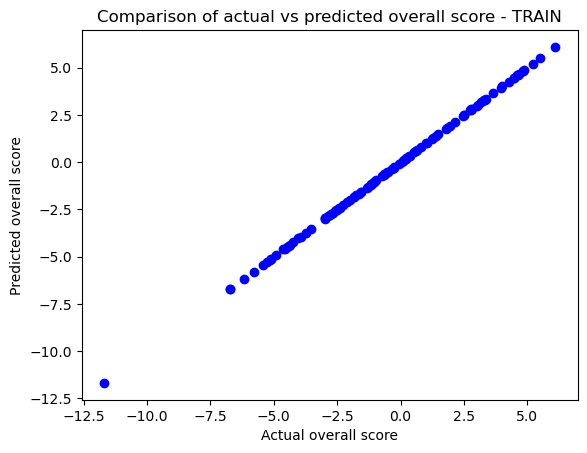

In [58]:
# Create a scatterplot.
plt.scatter(y_train,
            y_pred_train,
            color = 'blue')

# Set the title and legends for the graph.  
plt.title("Comparison of actual vs predicted overall score - TRAIN")
plt.xlabel("Actual overall score")
plt.ylabel("Predicted overall score")

# View the plot.
plt.show()

## Determine the accuracy of the model

The coefficient of determination R2 is influenced by the number of independent variables used. The more independent variables are included in the regression model, the greater the variance resolution R2. To take this into account, the adjusted R2 is used.

In [59]:
# Print R-squared value.
r_squared_train = lm.score(x_train, y_train)
print(f"R-squared value (train): {r_squared_train}") 


# print adjusted R-squared value
# Number of observations in the test data 
n = len(y_train) 
# Number of predictors (features) 
k = x_train.shape[1] 
# Calculate Adjusted R-squared 
adjusted_r_squared = 1 - ((1 - r_squared_train) * (n - 1) / (n - k - 1)) 
print(f"Adjusted R-squared value (train): {adjusted_r_squared}")

# Print the intercept value.
print("\nIntercept value (train):", lm.intercept_) 

# Print the coefficient value.
print("\nCoefficient value (train): ", lm.coef_)

# Print the MAE.   
print("\nMean Absolute Error (train):", metrics.mean_absolute_error(y_train,
                                                                    y_pred_train))  
# Print the MSE. 
mse = metrics.mean_squared_error(y_train,y_pred_train)

print("\nMean Square Error (train):", mse)  

# Print the RMSE. 
rmse_2 = math.sqrt(mse)

print("\nRoot Mean Square Error (train):", rmse_2)

R-squared value (train): 0.9999993583197964
Adjusted R-squared value (train): 0.9999992805403778

Intercept value (train): -0.000945742983247011

Coefficient value (train):  [-1.91005634e-06  1.00035709e+00  9.99831018e-01  9.99463431e-01
  1.00026402e+00  1.00072777e+00  9.99875689e-01  1.00049378e+00
  1.00016403e+00  9.99806432e-01  1.00008227e+00  2.42174631e-04]

Mean Absolute Error (train): 0.0021437339776934202

Mean Square Error (train): 7.202691226178056e-06

Root Mean Square Error (train): 0.002683783006537238


>with an $R^2$ = 0.99999 model seems to be overfitting. Therefore consider dropping intent to quit then reflexive.

In [60]:
#conduct VIF test dropping intent to quit
# Independent variables
x = survey_a.drop(columns = ['overall_score', 'manag_resp', 'sentiment', 'workloc', 'intent_quit'])

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

(141,)
(141, 11)
         feature       VIF
0       workleng  1.012734
1       involved  1.189428
2       autonomy  1.142418
3   direct_manag  1.283636
4     integrated  1.183478
5        welfare  1.535530
6       training  1.140497
7     work_press  1.200317
8      reflexive  2.286484
9     innovative  1.711699
10     customers  1.440296


>VIF for reflexive is 2.2 and the highest, so this will be dropped.
>
>Innovative will also be dropped at this stage, as it has virtually no correllation with overall_score

In [61]:
#conduct VIF test dropping intent to quit
# Independent variables
x = survey_a.drop(columns = ['overall_score', 'manag_resp', 'sentiment', 'workloc', 'intent_quit', 'reflexive', 'innovative'])

# Dependent variable
y = survey_a['overall_score']

# View the DataFrames.
print(y.shape)
print(x.shape)

# VIF DataFrame.
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns

# Calculating VIF for each feature.
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                          for i in range(len(x.columns))]

# View the output.
print(vif_data)

(141,)
(141, 9)
        feature       VIF
0      workleng  1.011702
1      involved  1.173931
2      autonomy  1.114439
3  direct_manag  1.233384
4    integrated  1.032665
5       welfare  1.474493
6      training  1.115633
7    work_press  1.175559
8     customers  1.307257


>VIF < 1.5, so happy with this.

#### Conduct the MLR again by first splitting the data

In [62]:
#x and y variables already specified above.
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size = 0.8,
                                                    random_state = 100)

There is no output or error message, which indicates that Python is happy with the code snippet.

### Fit the model

In [63]:
# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(x_train, y_train) 

LinearRegression()

> The output – `LinearRegression()` – signifies that a linear model has been successfully generated using the values of `x` and `y`.

### Predict the training set values

In [64]:
# Predict the training set values.
#create a new variable y_pred_train to store the `lm.predict()` method
y_pred_train = lm.predict(x_train) 

# View the output
print(y_pred_train.shape)
y_pred_train

(112,)


array([ -1.42088   ,  -0.10900638,   2.85663836,   3.55886285,
         4.10784833,  -4.388567  ,   1.52678099,   2.61880588,
        -4.15229008,  -0.50033222,  -3.25421365,   3.54869751,
         2.04662379,  -1.8947677 ,  -1.93708275,  -0.81729928,
        -1.45862306,  -4.92813648,   3.51926149,   4.71127548,
        -0.97641922,   2.48329035,  -5.84603592,  -6.36000181,
        -2.17364124,  -1.62448459,  -0.55977399,   0.26518646,
         1.89063575,  -3.33687797,   0.77933046,   4.77903965,
         2.79507113,   0.1594199 ,   1.22291156,   2.92522127,
        -3.67581474,  -2.55334619,  -2.89864504,  -1.70687007,
        -4.48517099,   0.26114526,   6.188677  ,   3.66001555,
        -3.18646155,   2.66867071,   3.36074095,  -5.65703695,
        -4.86272535,   0.55429082,  -5.21761699,  -0.3230881 ,
        -5.25330367,  -4.79637177,  -2.50137365,   0.08468386,
        -3.32956147,   1.39857889,  -4.26581403,   2.50741167,
         1.29166248,   1.44188888,   3.6445337 ,   1.90

> The output lists all the possible predicted values of the train data set.

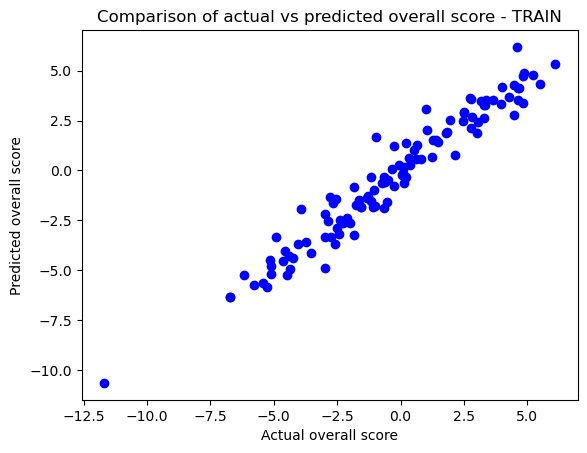

In [65]:
# Create a scatterplot.
plt.scatter(y_train,
            y_pred_train,
            color = 'blue')

# Set the title and legends for the graph.  
plt.title("Comparison of actual vs predicted overall score - TRAIN")
plt.xlabel("Actual overall score")
plt.ylabel("Predicted overall score")

# View the plot.
plt.show()

## Determine the accuracy of the model

In [66]:
# Print R-squared value.
r_squared_train = lm.score(x_train, y_train)
print(f"R-squared value (train): {r_squared_train}") 


# print adjusted R-squared value
# Number of observations in the test data 
n = len(y_train) 
# Number of predictors (features) 
k = x_train.shape[1] 
# Calculate Adjusted R-squared 
adjusted_r_squared = 1 - ((1 - r_squared_train) * (n - 1) / (n - k - 1)) 
print(f"Adjusted R-squared value (train): {adjusted_r_squared}")

# Print the intercept value.
print("\nIntercept value (train):", lm.intercept_) 

# Print the coefficient value.
print("\nCoefficient value (train): ", lm.coef_)

# Print the MAE.   
print("\nMean Absolute Error (train):", metrics.mean_absolute_error(y_train,
                                                                    y_pred_train))  
# Print the MSE. 
mse = metrics.mean_squared_error(y_train,y_pred_train)

print("\nMean Square Error (train):", mse)  

# Print the RMSE. 
rmse_2 = math.sqrt(mse)

print("\nRoot Mean Square Error (train):", rmse_2)

R-squared value (train): 0.9453953846477944
Adjusted R-squared value (train): 0.9405773303520115

Intercept value (train): -0.04650248472553414

Coefficient value (train):  [0.00749067 1.02332431 1.09492316 1.09073571 1.2348358  0.89475984
 1.01376983 0.95446143 0.87859316]

Mean Absolute Error (train): 0.5834754684839359

Mean Square Error (train): 0.6129224209451155

Root Mean Square Error (train): 0.7828936204524313


> With a data split of 80:20, the following results were obtained for the train data:
> - $R^2=0.945$ and adjusted $R^2=0.941$: The goodness of fit is approximately 94.1%, which indicates a very strong positive correlation between `overall score`($y$) and the independent variables $x$s.
> - $\beta_0=-0.0465$: The value of $y$ overall_score when all the ($x$s) are equal to zero.
> - $\beta_1$: The values describes the direction and strength of the relationship between the two variables. 
> - MAE and MSE: The respective values are 0.584 and 0.0.613.
> - RMSE: The value is 0.783.

## Evaluate the model

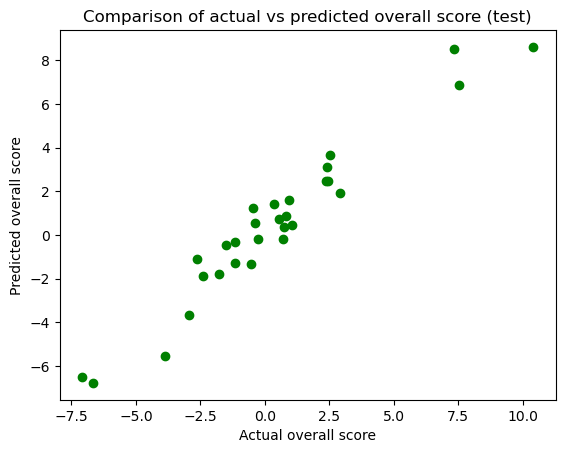

In [67]:
# Predict the test set values.
# Create a new variable (e.g. y_pred_test) to store the lim.predict() method, and specify the X_test data set.
y_pred_test = lm.predict(x_test) 

# Create a scatterplot.
plt.scatter(y_test, y_pred_test, color = 'green')

# Set the title and legends for the graph.  
plt.title("Comparison of actual vs predicted overall score (test)")
plt.xlabel("Actual overall score")
plt.ylabel("Predicted overall score")

# Print the graph. 
plt.show() 

In [68]:
# Print R-squared value.
r_squared_test = lm.score(x_test, y_test)
print(f"R-squared value (test): {r_squared_test}") 


# print adjusted R-squared value
# Number of observations in the test data 
n = len(y_test) 
# Number of predictors (features) 
k = x_test.shape[1] 
# Calculate Adjusted R-squared 
adjusted_r_squared = 1 - ((1 - r_squared_test) * (n - 1) / (n - k - 1)) 
print(f"Adjusted R-squared value (test): {adjusted_r_squared}")

# Print the intercept value.
print("\nIntercept value: (test)", lm.intercept_) 

# Print the coefficient value.
print("\nCoefficient value: (test)", lm.coef_)

# Print the MAE.   
print("\nMean Absolute Error (test):", metrics.mean_absolute_error(y_test,
                                                                   y_pred_test))  

# Print the MSE. 
print("\nMean Square Error (test):", metrics.mean_squared_error(y_test,
                                                                y_pred_test))  

# Print the RMSE. 
rmse_2 = math.sqrt(metrics.mean_squared_error(y_test,
                                              y_pred_test))

print("\nRoot Mean Square Error (test):", rmse_2)

R-squared value (test): 0.9405443952805324
Adjusted R-squared value (test): 0.9123812140976266

Intercept value: (test) -0.04650248472553414

Coefficient value: (test) [0.00749067 1.02332431 1.09492316 1.09073571 1.2348358  0.89475984
 1.01376983 0.95446143 0.87859316]

Mean Absolute Error (test): 0.7243395623148601

Mean Square Error (test): 0.8017475465094249

Root Mean Square Error (test): 0.8954035662813863


> With a data split of 80:20, the following results were obtained for the test:
> - $R^2$ = 0.941 and adjusted $R^2=0.912$: The goodness of fit is approximately 91.2%, which indicates a very strong positive correlation between `overall score`($y$) and the independent variables $x$s.
> - $\beta_0=-0.047$: The value of $y$ overall_score when all the ($x$s) are equal to zero.
> - $\beta_1$: The values describes the direction and strength of the relationship between the two variables. 
> - MAE and MSE: The respective values are 0.724 and 0.802
> - RMSE: The value is 0.895.

> The outputs of the train and test data are virtually the same

## Compare actual versus predicted data

In [69]:
# Predict values.
#Create a variable (e.g. pre_y_df) to store the output as a DataFrame.
pred_y_df = pd.DataFrame({'Actual value':y_test,
                          'Predicted value':y_pred_test,
                          'Difference (residual)':y_test-y_pred_test})

# View the DataFrame.
pred_y_df.head(20)

,Actual value,Predicted value,Difference (residual)
63,-0.48,1.231670,-1.711670
124,-0.26,-0.193602,-0.066398
141,0.80,0.844613,-0.044613
117,-2.94,-3.661749,0.721749
30,-2.62,-1.099126,-1.520874
114,7.33,8.509528,-1.179528
46,-1.50,-0.448660,-1.051340
102,-2.39,-1.897142,-0.492858
38,0.69,-0.206832,0.896832
111,2.46,2.458469,0.001531


> very small differences betwen actual and predicted y-values

### Confirm homogeneity of variables

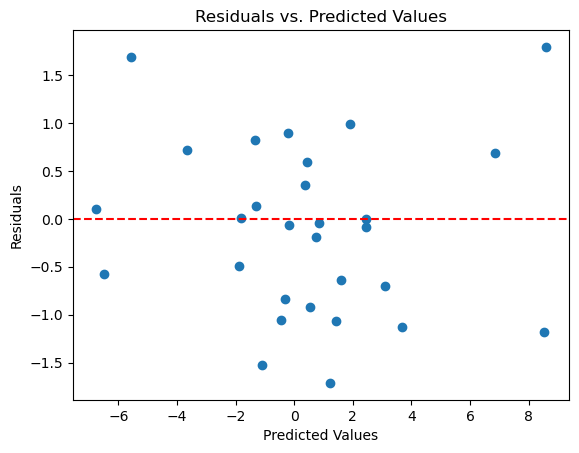

In [70]:
#Determine Homogeneity of variances

plt.scatter(pred_y_df['Predicted value'], pred_y_df['Difference (residual)'])
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()


>the spread of residuals remains constant (no funneling or systematic pattern), suggesting homoscedasticity.


In [71]:
#use the Breusch-Pagan test to statistically test for homoscedasticity
import statsmodels.stats.api as sms
from statsmodels.tools.tools import add_constant

# Use predicted values as the independent variable with a constant term
x_pred_with_constant = add_constant(pred_y_df['Predicted value'])
residuals = pred_y_df['Difference (residual)']

# Perform the Breusch-Pagan test
test = sms.het_breuschpagan(residuals, x_pred_with_constant)
print("Lagrange Multiplier p-value:", test[1])  # p-value


Lagrange Multiplier p-value: 0.2256112720013909


>as the p-value > 0.05, the variances are not significantly different and supports the assumption of homoscedasticity (equal variance).

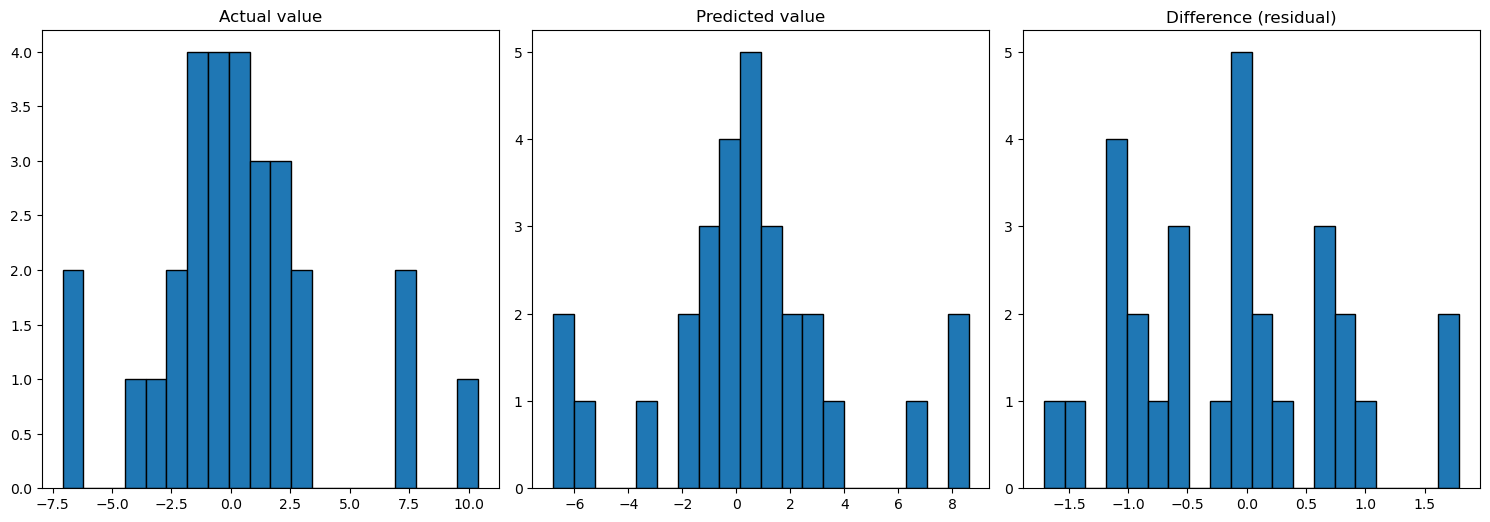

In [72]:
# Create the histograms for each column in the DataFrame
ax = pred_y_df.hist(figsize=(15, 20), bins=20, layout=(4, 3), edgecolor='black')

# Loop through each subplot to remove grid lines 
for subplot in ax.flatten(): 
    subplot.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

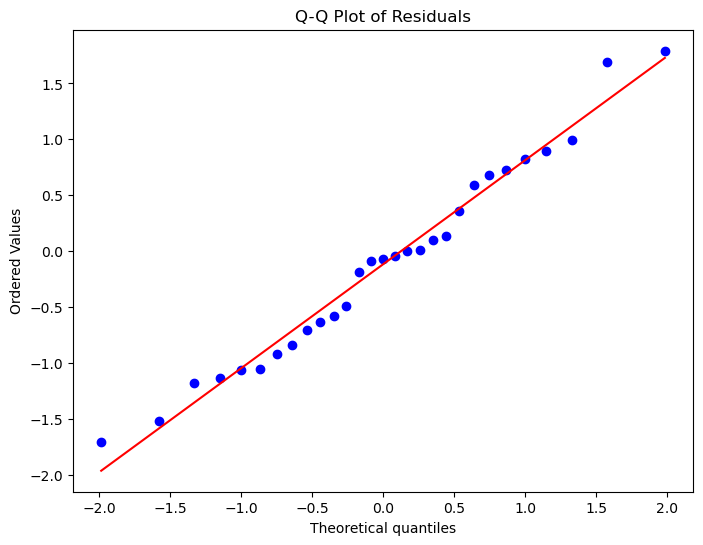

In [73]:
# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(pred_y_df['Difference (residual)'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()


X-axis (Theoretical Quantiles): These represent the quantiles of a standard normal distribution (i.e., what would be expected if the residuals were perfectly normally distributed).
Y-axis (Ordered Values): These represent the actual quantiles of the residuals from your model.
Blue Points: Each point represents a quantile of the residuals.
Red Line: The reference line representing a perfectly normal distribution. 
The points lie mostly along the red line, with only minor deviations, especially at the tails (extremes).
This alignment indicates that the residuals are approximately normally distributed, with no significant deviations from normality. However, there are some slight deviations in the upper and lower ends, but they are not severe.

## Make predictions

Equation is as follows:
overall_score=−0.0465+(0.0075×workleng)+(1.0233×involved)+(1.0949×autonomy)+(1.0907×direct_manag)+(1.2348×integrated)+(0.8948×welfare)+(1.0138×training)+(0.9545×work_press)+(0.8786×customers)

Rewritten to place the independent variables in descending order of their influence on overall_score.

overall_score = -0.0465 + (1.2348 × integrated) + (1.0949 × autonomy) + (1.0907 × direct_manag) + (1.0233 × involved) + (1.0138 × training) + (0.9545 × work_press) + (0.8948 × welfare) + (0.8786 × customers) + (0.0075 × workleng)

According to the model, integrated has the most influence on the overall score, followed by autonomy and direct_manag. 

To illustrate the influence of independent variables on the overall OC score, the following scenarios were provided:

- Two groups based on length of work (lowest and highest values):
  - **Group 1**: `workleng = 3` (length at company 0 to 5 years)
  - **Group 2**: `workleng = 23` (more than 20 years)

- For each group, the following options for independent variables were investigated:

  - **Option 0**: All variables = 0 (neutral, neither positive nor negative)
  - **Option 1**: `integrated = +5` (maximum), all other variables = 0
  - **Option 2**: `autonomy = +5`, all other variables = 0
  - **Option 3**: `direct_manag = +5`, all other variables = 0
  - **Option 4**: `training = +5` (this was one of the lowest-scoring variables in the original data), all other variables = 0


In [74]:
#predict for following scenarios:
#group1, workleng=3, 
#group2, workleng=23, 

#For both group, OC variables:
#Option0 = all OC variables = 0
#Option1 =  integrated = +5, all others = 0
#Option2 = autonomy = +5,  all others = 0
#Option3 = direct_manag = +5,  all others = 0
#Option4 = training = +5, all others = 0 


# Option 0: all variables = 0
group1_option0 = lm.predict([[3, 0, 0, 0, 0, 0, 0, 0, 0]])
group2_option0 = lm.predict([[23, 0, 0, 0, 0, 0, 0, 0, 0]])

# Option 1: integrated= +5, all others  = 0
group1_option1 = lm.predict([[3, 0, 0, 0, 5, 0, 0, 0, 0]])
group2_option1 = lm.predict([[23, 0, 0, 0, 5, 0, 0, 0, 0]])

# Option 2: autonomy = +5, all others = 0
group1_option2 = lm.predict([[3, 0, 5, 0, 0, 0, 0, 0, 0]])
group2_option2 = lm.predict([[23, 0, 5, 0, 0, 0, 0, 0, 0]])

# Option 3: direct_manag = +5, all others  = 0
group1_option3 = lm.predict([[3, 0, 0, 5, 0, 0, 0, 0, 0]])
group2_option3 = lm.predict([[23, 0, 0, 5, 0, 0, 0, 0, 0]])


# Option 4: training = +5, all others = 0 
group1_option4 = lm.predict([[3, 0, 0, 0, 0, 0, 5, 0, 0]])
group2_option4 = lm.predict([[23, 0, 0, 0, 0, 0, 5, 0, 0]])



# Display predictions
print("Predictions:")

print(f"Group 1, Option 0 (workleng=3, all = 0): {group1_option0[0]:.3f}")
print(f"Group 2, Option 0 (workleng=23, all = 0): {group2_option0[0]:.3f}")
print()

print(f"Group 1, Option 1 (workleng=3, integrated = +5): {group1_option1[0]:.3f}")
print(f"Group 2, Option 1 (workleng=23, integrated = +5): {group2_option1[0]:.3f}")
print()

print(f"Group 1, Option 2 (workleng=3, autonomy = +5): {group1_option2[0]:.3f}")
print(f"Group 2, Option 2 (workleng=23, autonomy = +5): {group2_option2[0]:.3f}")
print()

print(f"Group 1, Option 3 (workleng=3, direct_manag = +5): {group1_option3[0]:.3f}")
print(f"Group 2, Option 3 (workleng=23, direct_manag = +5): {group2_option3[0]:.3f}")
print()


print(f"Group 1, Option 4 (workleng=3, training = +5): {group1_option4[0]:.3f}")
print(f"Group 2, Option 4 (workleng=23, training = +5): {group2_option4[0]:.3f}")
print()

Predictions:
Group 1, Option 0 (workleng=3, all = 0): -0.024
Group 2, Option 0 (workleng=23, all = 0): 0.126

Group 1, Option 1 (workleng=3, integrated = +5): 6.150
Group 2, Option 1 (workleng=23, integrated = +5): 6.300

Group 1, Option 2 (workleng=3, autonomy = +5): 5.451
Group 2, Option 2 (workleng=23, autonomy = +5): 5.600

Group 1, Option 3 (workleng=3, direct_manag = +5): 5.430
Group 2, Option 3 (workleng=23, direct_manag = +5): 5.579

Group 1, Option 4 (workleng=3, training = +5): 5.045
Group 2, Option 4 (workleng=23, training = +5): 5.195



>The results indicate that when all other predictive variables remain neutral (neither positive or negative), those that have been at the company the least have lower overall OC score than those that have been with the company the longest. These differences are seen across all the options. In addition, integrated (whether the employee felt to be part of a team), had the most influence on overall OC score compared to autonomy (feeling trusted to do their job independently), direct_mang (having a positive relationship with their direct manager) and training (feel they get enough training to do their job effectively).